<a href="https://colab.research.google.com/github/TimurMMD/ML_projects/blob/main/Medical_Appointment_Scheduling_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This dataset is created to train and test ML models with Appointment Scheduling System
## The data is taken from [Kaggle](https://www.kaggle.com/datasets/carogonzalezgaltier/medical-appointment-scheduling-system/data)


## The notebook has the following structure:

*   ## 1. Import
*   ## 2. EDA
      * ### 2.1. Data inspection
      * ### 2.2. Exploratory Data Analysis
        * #### 2.2.1. Values Distribution
        * #### 2.2.2. Gender Dependency
        * #### 2.2.3. Scheduling interval dependency
        * #### 2.2.4. Status & Insurance company
        * #### 2.2.5. Appointment date & date distribution
*   ## 3. Preprocessing
      * ### 3.1. Cleansing
      * ### 3.2. Dropping
      * ### 3.3. Feature Engineering
      * ### 3.4. Correlation check
      * ### 3.5. Splitting
      * ### 3.6. Sampling
      * ### 3.7. Scaling
*   ## 4. Training
      * ### 4.1. Random Forest
      * ### 4.2. XGBoost
      * ### 4.3. LightGBM
      * ### 4.4. CatBoost






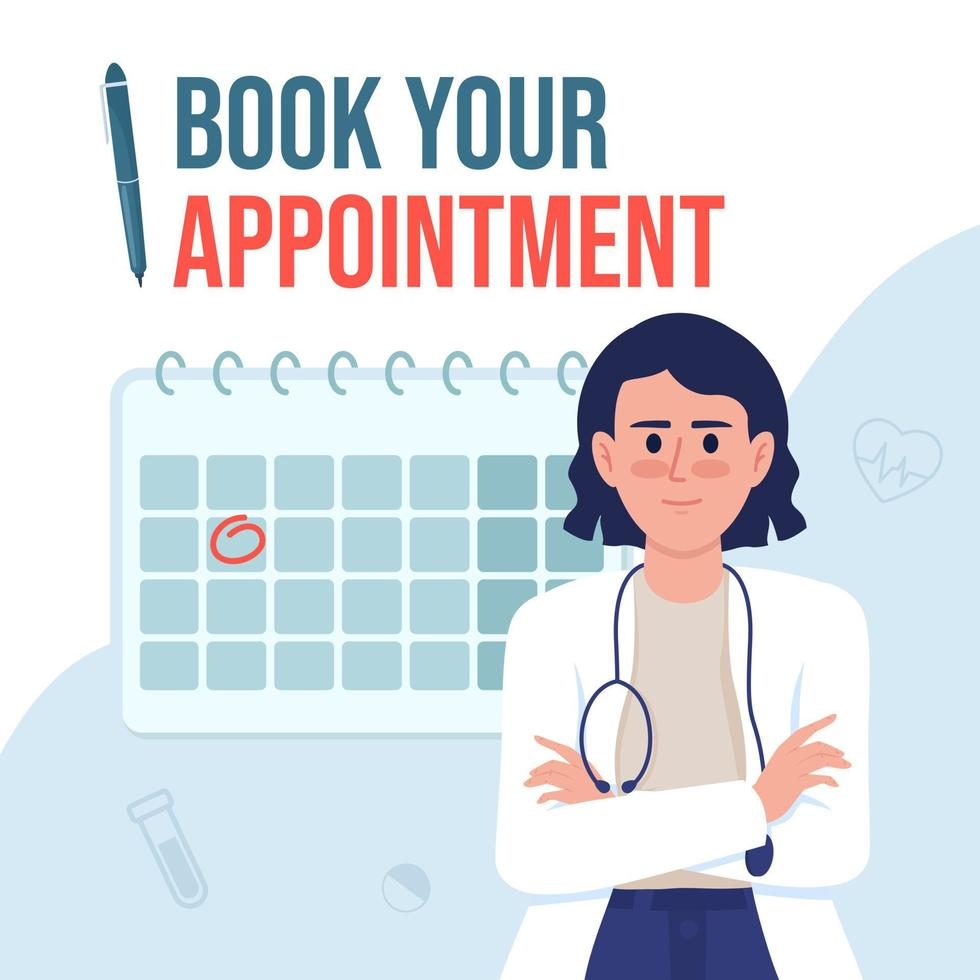

# 1. Import

### Firstly we import data from Kaggle with the help of provided code

In [ ]:
# Install and import
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
pip install catboost

In [ ]:
# Imported libraries are going to be there
# All other libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import calendar
import numpy as np
from scipy.stats import randint, uniform, boxcox, probplot
from tqdm.notebook import tqdm
from joblib import Parallel, parallel_backend, register_parallel_backend
import time
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, _search
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, auc, roc_curve, precision_recall_curve, average_precision_score

# Machine Learning models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, plot_importance
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV

In [ ]:
file_path_app = "appointments.csv"
file_path_pat = "patients.csv"
file_path_slot = "slots.csv"
# Load dataset directly into pandas
df_app = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "carogonzalezgaltier/medical-appointment-scheduling-system",
    file_path_app
)


df_pat = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "carogonzalezgaltier/medical-appointment-scheduling-system",
    file_path_pat
)

df_slot = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "carogonzalezgaltier/medical-appointment-scheduling-system",
    file_path_slot
)


/tmp/ipython-input-792064878.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_app = kagglehub.load_dataset(


Using Colab cache for faster access to the 'medical-appointment-scheduling-system' dataset.


/tmp/ipython-input-792064878.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_pat = kagglehub.load_dataset(


Using Colab cache for faster access to the 'medical-appointment-scheduling-system' dataset.


/tmp/ipython-input-792064878.py:18: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_slot = kagglehub.load_dataset(


Using Colab cache for faster access to the 'medical-appointment-scheduling-system' dataset.


# 2. EDA

## 2.1. Data inspection

In [ ]:
df_app

,appointment_id,slot_id,scheduling_date,appointment_date,appointment_time,scheduling_interval,status,check_in_time,appointment_duration,start_time,end_time,waiting_time,patient_id,sex,age,age_group
0,138,1,2014-12-28,2015-01-01,08:00:00,4,did not attend,NaN,NaN,NaN,NaN,NaN,8285,Male,37,35-39
1,146,23,2014-12-29,2015-01-01,13:30:00,3,did not attend,NaN,NaN,NaN,NaN,NaN,5972,Male,84,80-84
2,21,24,2014-12-17,2015-01-01,13:45:00,15,attended,13:36:45,5.2,13:37:57,13:43:09,1.2,6472,Male,77,75-79
3,233,25,2014-12-31,2015-01-01,14:00:00,1,attended,13:59:32,28.9,14:00:40,14:29:34,1.1,5376,Female,37,35-39
4,90,26,2014-12-26,2015-01-01,14:15:00,6,cancelled,NaN,NaN,NaN,NaN,NaN,8028,Male,72,70-74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111483,111378,104015,2024-12-01,2024-12-19,11:30:00,18,scheduled,NaN,NaN,NaN,NaN,NaN,10587,Female,36,35-39
111484,111379,104053,2024-12-01,2024-12-20,11:00:00,19,scheduled,NaN,NaN,NaN,NaN,NaN,36138,Male,34,30-34
111485,111380,104068,2024-12-01,2024-12-20,14:45:00,19,scheduled,NaN,NaN,NaN,NaN,NaN,1716,Female,97,90+
111486,111428,104100,2024-12-01,2024-12-23,12:45:00,22,scheduled,NaN,NaN,NaN,NaN,NaN,30412,Male,87,85-89


In [ ]:
df_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111488 entries, 0 to 111487
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   appointment_id        111488 non-null  int64  
 1   slot_id               111488 non-null  int64  
 2   scheduling_date       111488 non-null  object 
 3   appointment_date      111488 non-null  object 
 4   appointment_time      111488 non-null  object 
 5   scheduling_interval   111488 non-null  int64  
 6   status                111488 non-null  object 
 7   check_in_time         86032 non-null   object 
 8   appointment_duration  86032 non-null   float64
 9   start_time            86032 non-null   object 
 10  end_time              86032 non-null   object 
 11  waiting_time          86032 non-null   float64
 12  patient_id            111488 non-null  int64  
 13  sex                   111488 non-null  object 
 14  age                   111488 non-null  int64  
 15  

In [ ]:
df_app['status'].value_counts()

,count
status,
attended,86032
cancelled,18254
did not attend,6615
unknown,446
scheduled,141


In [ ]:
df_app.describe()

,appointment_id,slot_id,scheduling_interval,appointment_duration,waiting_time,patient_id,age
count,111488.000000,111488.000000,111488.000000,86032.000000,86032.000000,111488.000000,111488.000000
mean,55744.500000,51854.320438,7.190146,17.479525,44.086509,13783.228581,57.205206
std,32183.957743,29945.828944,6.146793,11.064225,40.788791,9722.943016,20.158119
min,1.000000,1.000000,1.000000,0.000000,0.600000,1.000000,15.000000
25%,27872.750000,25909.750000,2.000000,8.600000,12.600000,5702.000000,40.000000
50%,55744.500000,51852.000000,5.000000,15.800000,33.500000,11816.000000,59.000000
75%,83616.250000,77796.250000,10.000000,24.700000,64.600000,20736.250000,74.000000
max,111488.000000,104159.000000,30.000000,58.700000,297.300000,36697.000000,100.000000


In [ ]:
df_app['sex'].value_counts()

,count
sex,
Female,66086
Male,45402


## 2.2. Exploratory Data Analysis

### 2.2.1. Values distribution

In [ ]:
# Firstly let's build some simple charts to het visual understanding of the data distribution

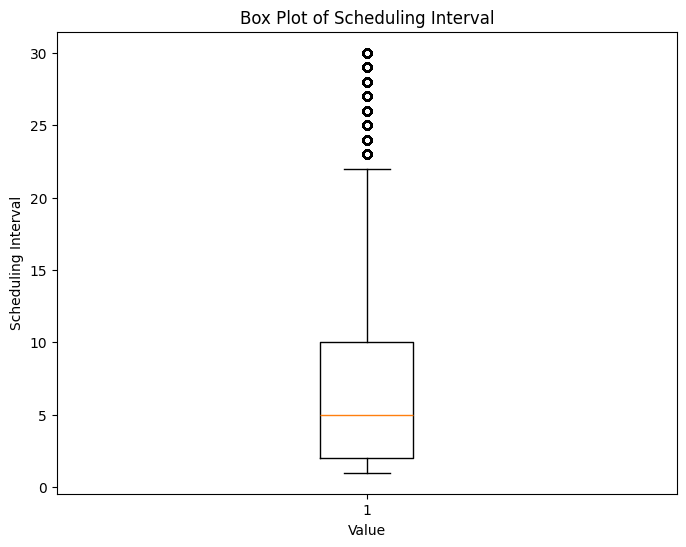

In [ ]:
plt.figure(figsize=(8,6))
plt.boxplot(df_app['scheduling_interval'])
plt.xlabel('Value')
plt.ylabel('Scheduling Interval')
plt.title('Box Plot of Scheduling Interval')
plt.show()

#### The scheduling interval is mainly distributed between 2-3 and 10 days with extremes on 1 and 30. We should carefully check the cases with scheduling more than 10 days.

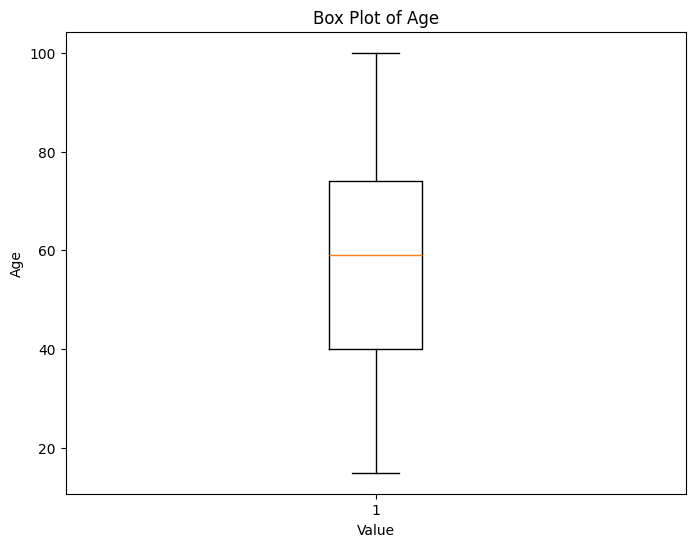

In [ ]:
plt.figure(figsize=(8,6))
plt.boxplot(df_app['age'])
plt.xlabel('Value')
plt.ylabel('Age')
plt.title('Box Plot of Age')
plt.show()


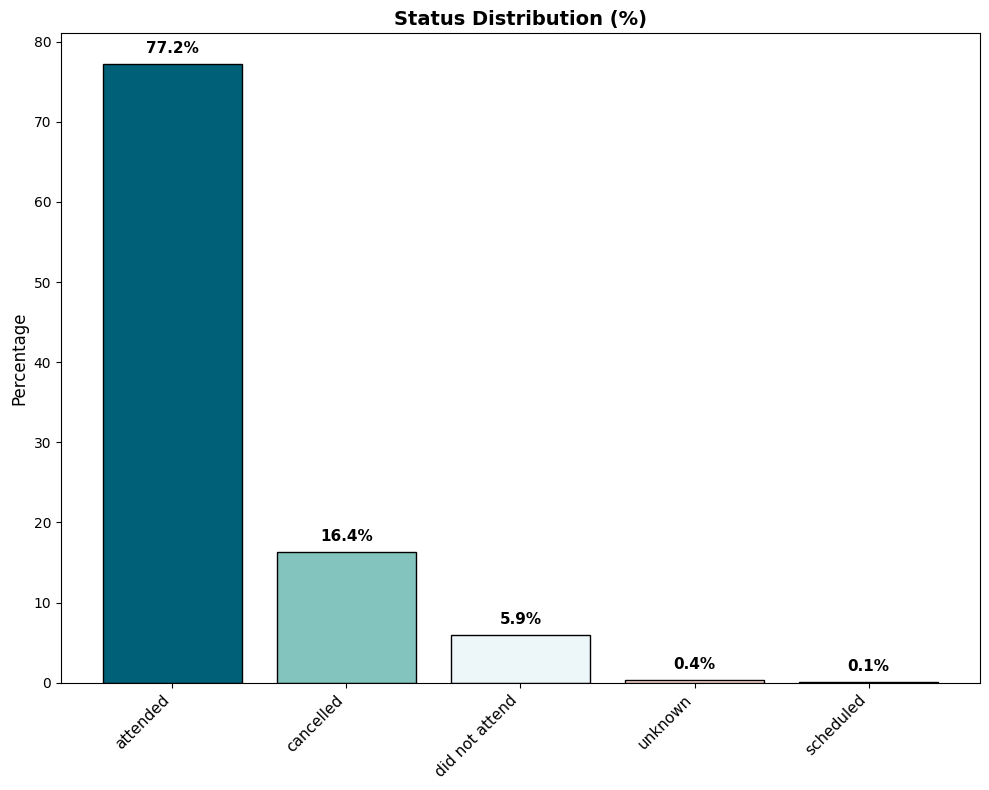

In [ ]:
status_counts = df_app['status'].value_counts(normalize=True) * 100

# Color - Ocean Pearl Delight
colors = ['#006077', '#83C5BE', '#EDF6F9', '#FFDDD2', '#E29578']

plt.figure(figsize=(10,8))
bars = plt.bar(
    status_counts.index,
    status_counts.values,
    color=colors[:len(status_counts)],
    edgecolor='black'
)


for bar, value in zip(bars, status_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,  # position of percentage
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


plt.title('Status Distribution (%)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

#### The status data is imbalanced, this should be taken into account

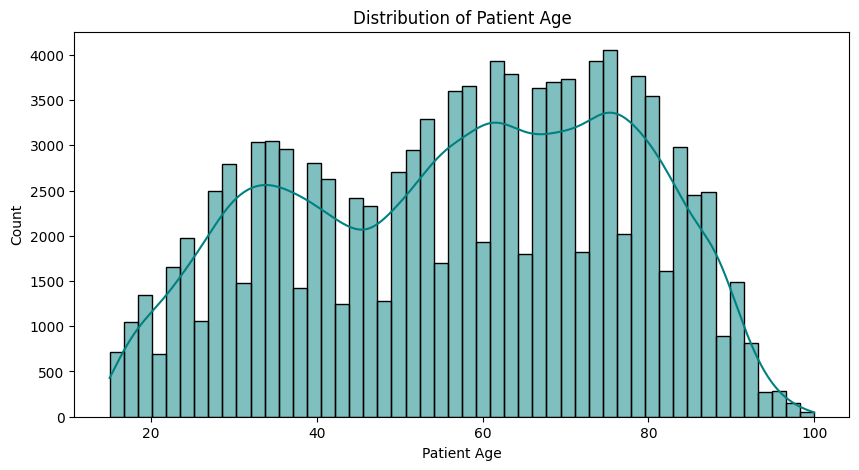

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_app['age'], bins=50, kde=True, color='teal')
plt.title('Distribution of Patient Age')
plt.xlabel('Patient Age')
plt.ylabel('Count')
plt.show()

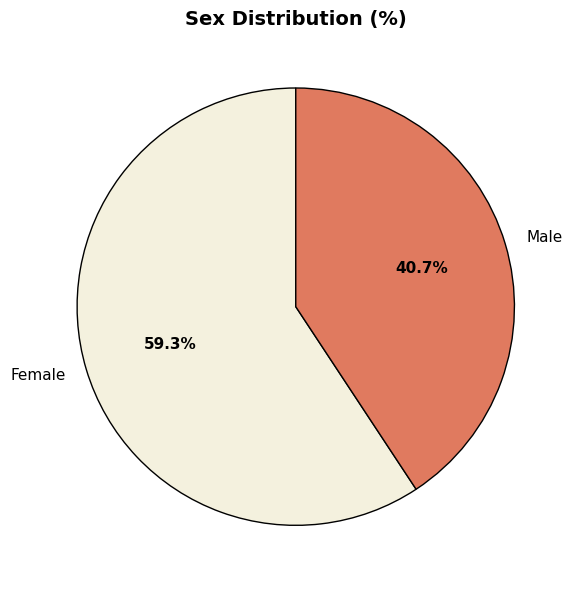

In [ ]:
sex_counts = df_app['sex'].value_counts(normalize=True) * 100

# Color - Flamingo Sunset
colors = ['#F4F1DE', '#E07A5F']

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(sex_counts)],
    textprops={'fontsize': 11, 'color': 'black'},
    wedgeprops={'edgecolor': 'black'}
)

plt.setp(autotexts, size=11, weight='bold')
plt.title('Sex Distribution (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### There is no equality on gender distribution, let's check if there any differences by gender and appointments being attended.

### 2.2.2. Gender Dependency

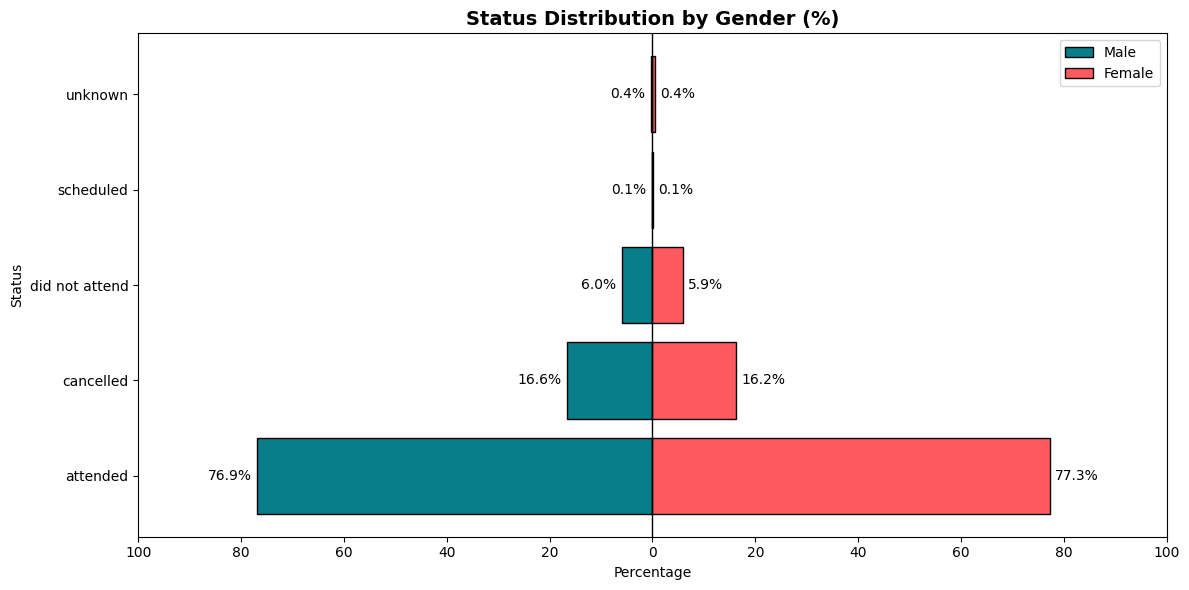

In [ ]:
male_status = (df_app[df_app['sex'] == 'Male']['status']
               .value_counts(normalize=True)
               .sort_index()) * 100
female_status = (df_app[df_app['sex'] == 'Female']['status']
                 .value_counts(normalize=True)
                 .sort_index()) * 100


statuses = sorted(df_app['status'].unique())
male_status = male_status.reindex(statuses, fill_value=0)
female_status = female_status.reindex(statuses, fill_value=0)


data = pd.DataFrame({
    'Status': statuses,
    'Male': -male_status,      # negative values to go left
    'Female': female_status    # positive values to go right
})


plt.figure(figsize=(12, 6))

# Color - Sapphire Fire
plt.barh(data['Status'], data['Male'], color='#087E8B', edgecolor='black', label='Male')
plt.barh(data['Status'], data['Female'], color='#FF5A5F', edgecolor='black', label='Female')

for i, (male, female) in enumerate(zip(data['Male'], data['Female'])):
    plt.text(male - 1, i, f'{abs(male):.1f}%', va='center', ha='right', color='black', fontsize=10)
    plt.text(female + 1, i, f'{female:.1f}%', va='center', ha='left', color='black', fontsize=10)


plt.axvline(0, color='black', linewidth=1)
plt.title('Status Distribution by Gender (%)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage')
plt.ylabel('Status')
plt.legend(loc='upper right')
xticks = plt.xticks()[0]
plt.xticks(xticks, [abs(int(x)) for x in xticks])
plt.tight_layout()
plt.show()


### 2.2.3. Scheduling interval dependency

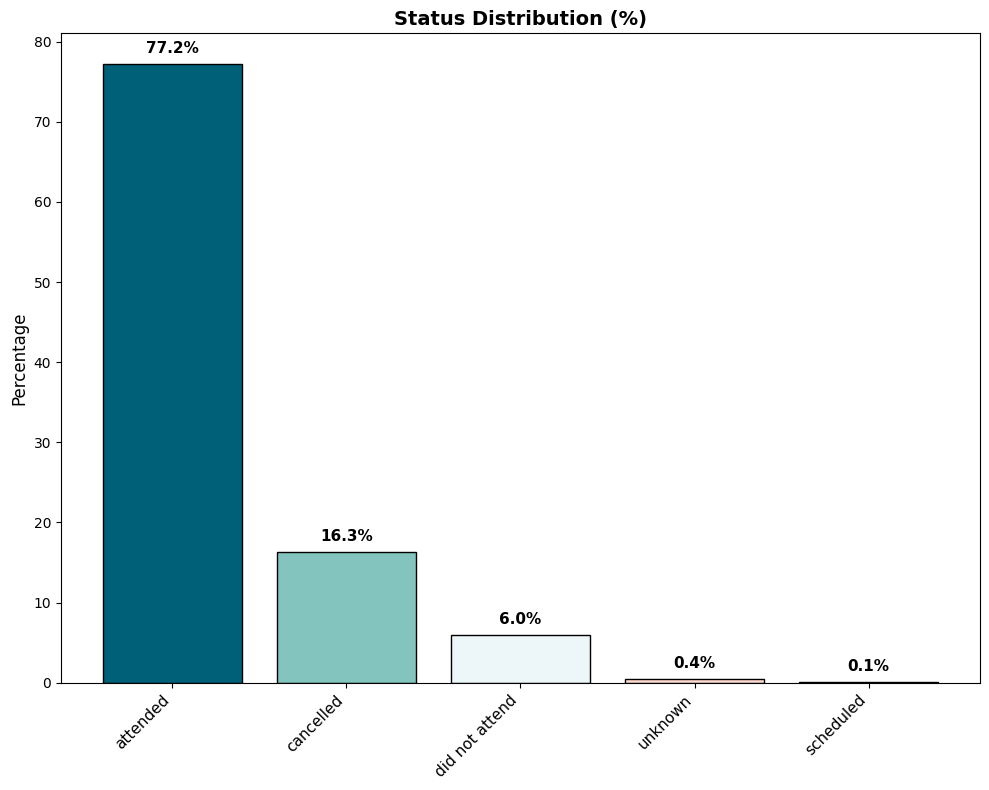

In [ ]:
# As a 75% of appointments were made 10 days or earlier, let's check the later 20 days separetely
sch_app = df_app[df_app['scheduling_interval'] > 10]

status_counts_sch = sch_app['status'].value_counts(normalize=True) * 100

# Color - Ocean Pearl Delight
colors = ['#006077', '#83C5BE', '#EDF6F9', '#FFDDD2', '#E29578']

plt.figure(figsize=(10,8))
bars = plt.bar(
    status_counts_sch.index,
    status_counts_sch.values,
    color=colors[:len(status_counts_sch)],
    edgecolor='black'
)


for bar, value in zip(bars, status_counts_sch.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,  # position of percentage
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


plt.title('Status Distribution (%)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

#### No difference with the general bar chart

In [ ]:
merged = pd.merge(df_app, df_pat, on='patient_id', how='left')

In [ ]:
merged_na = merged[(merged['status'] != 'attended')&(merged['status'] != 'scheduled')]

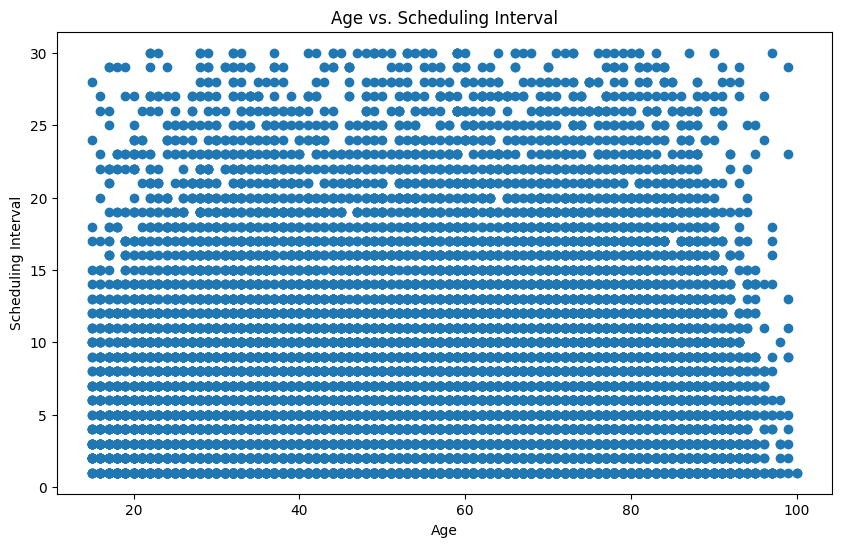

In [ ]:
# Decided to check the correlation between age and the scheduling interval
plt.figure(figsize=(10,6))
plt.scatter(merged_na['age'], merged_na['scheduling_interval'])
plt.xlabel('Age')
plt.ylabel('Scheduling Interval')
plt.title('Age vs. Scheduling Interval')
plt.show()

# The chart is incomprehensible, no dependency here

### 2.2.4. Status & Insurance company

#### Here I want to merge patients table with the appointment table and check whether for some patients from specific insurance companies it was more often to not attend or cancel the appointment

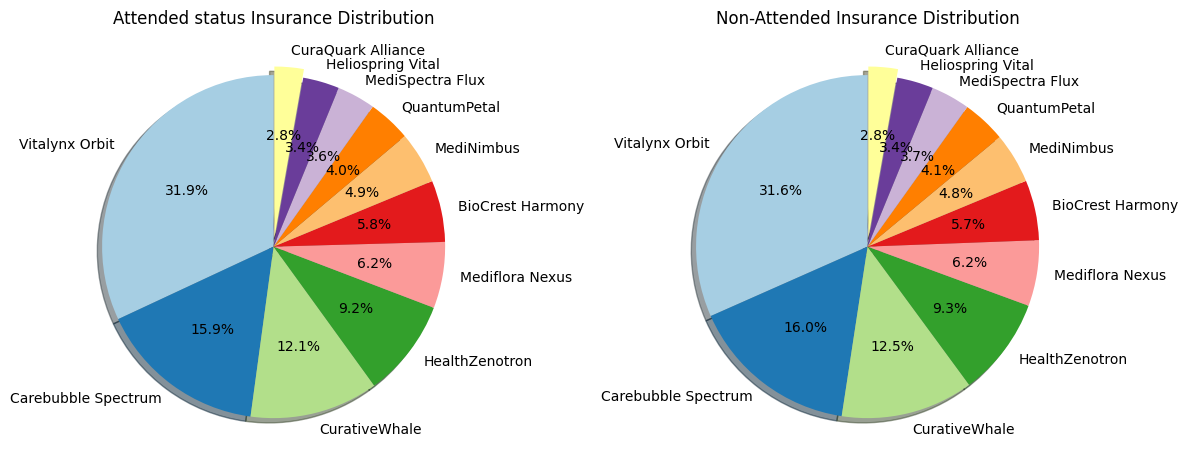

In [ ]:
natt_values = merged_na['insurance'].value_counts(normalize=True)*100
att_values = merged[merged['status'] == 'attended']['insurance'].value_counts(normalize=True)*100


colors = plt.cm.Paired.colors

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# General dataset pie chart
axes[0].pie(
    att_values,
    labels=att_values.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.05 if i == att_values.min() else 0 for i in att_values],
    shadow=True
)
axes[0].set_title('Attended status Insurance Distribution')

# Specific dataset pie chart
axes[1].pie(
    natt_values,
    labels=natt_values.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.05 if i == natt_values.min() else 0 for i in natt_values],
    shadow=True
)
axes[1].set_title('Non-Attended Insurance Distribution')

plt.tight_layout()
plt.show()

### 2.2.5. Appointment time and date distribution

In [ ]:
df_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111488 entries, 0 to 111487
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   appointment_id        111488 non-null  int64  
 1   slot_id               111488 non-null  int64  
 2   scheduling_date       111488 non-null  object 
 3   appointment_date      111488 non-null  object 
 4   appointment_time      111488 non-null  object 
 5   scheduling_interval   111488 non-null  int64  
 6   status                111488 non-null  object 
 7   check_in_time         86032 non-null   object 
 8   appointment_duration  86032 non-null   float64
 9   start_time            86032 non-null   object 
 10  end_time              86032 non-null   object 
 11  waiting_time          86032 non-null   float64
 12  patient_id            111488 non-null  int64  
 13  sex                   111488 non-null  object 
 14  age                   111488 non-null  int64  
 15  

In [ ]:
# Change the data type of columns
df_app['appointment_date'] = pd.to_datetime(df_app['appointment_date'], errors='coerce')
df_app['appointment_time'] = pd.to_datetime(df_app['appointment_time'], format='%H:%M:%S', errors='coerce').dt.time

In [ ]:
# Extract year, month and hour from date and time columns and created new columns
df_app['year'] = df_app['appointment_date'].dt.year
df_app['month'] = df_app['appointment_date'].dt.month
df_app['hour'] = pd.to_datetime(df_app['appointment_time'], format='%H:%M:%S', errors='coerce').dt.hour

In [ ]:
# Create a new column with the month name to have a more visually attractive charts
df_app['month_name'] = df_app['appointment_date'].dt.month.apply(lambda x: calendar.month_abbr[x])
monthly_counts = df_app.groupby(['year', 'month_name']).size().reset_index(name='count')
pivot_df = monthly_counts.pivot(index='year', columns='month_name', values='count').fillna(0)
month_order = list(calendar.month_abbr)[1:]  # ['Jan', 'Feb', ..., 'Dec']
pivot_df = (
    monthly_counts
    .pivot(index='year', columns='month_name', values='count')
    .reindex(columns=month_order)
    .fillna(0)
)

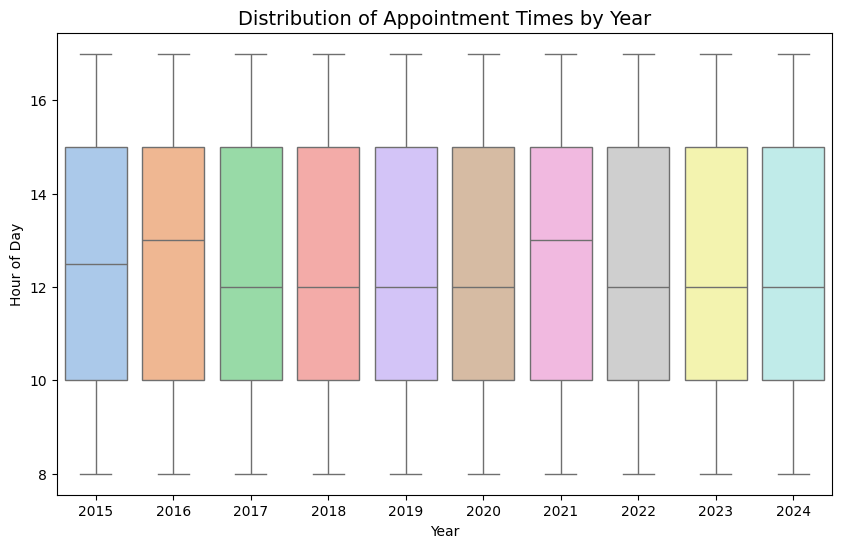

In [ ]:
# Distribution of appointments by year
plt.figure(figsize=(10,6))
sns.boxplot(x='year', y='hour', data=df_app, palette='pastel')
plt.title('Distribution of Appointment Times by Year', fontsize=14)
plt.ylabel('Hour of Day')
plt.xlabel('Year')
plt.show()

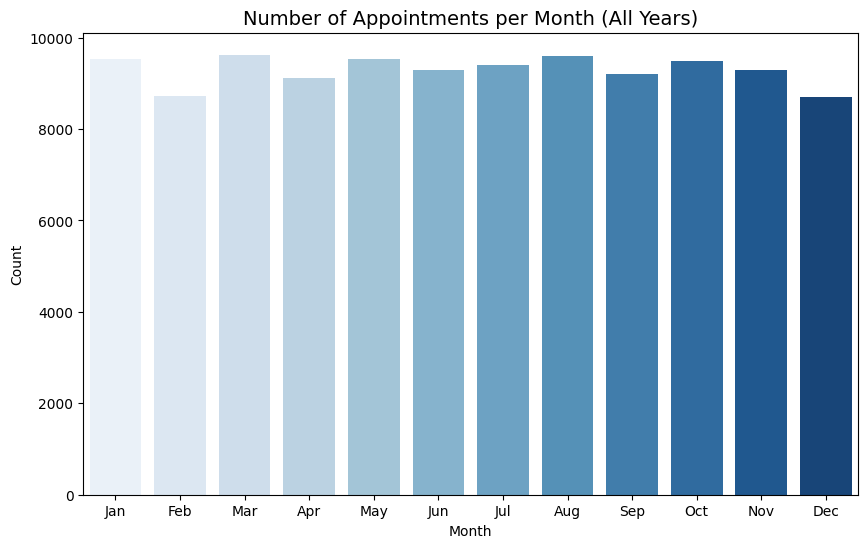

In [ ]:
# Total distribution of number of appointments per month throughout all years
plt.figure(figsize=(10,6))
sns.countplot(x='month_name', data=df_app, palette='Blues')
plt.title('Number of Appointments per Month (All Years)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

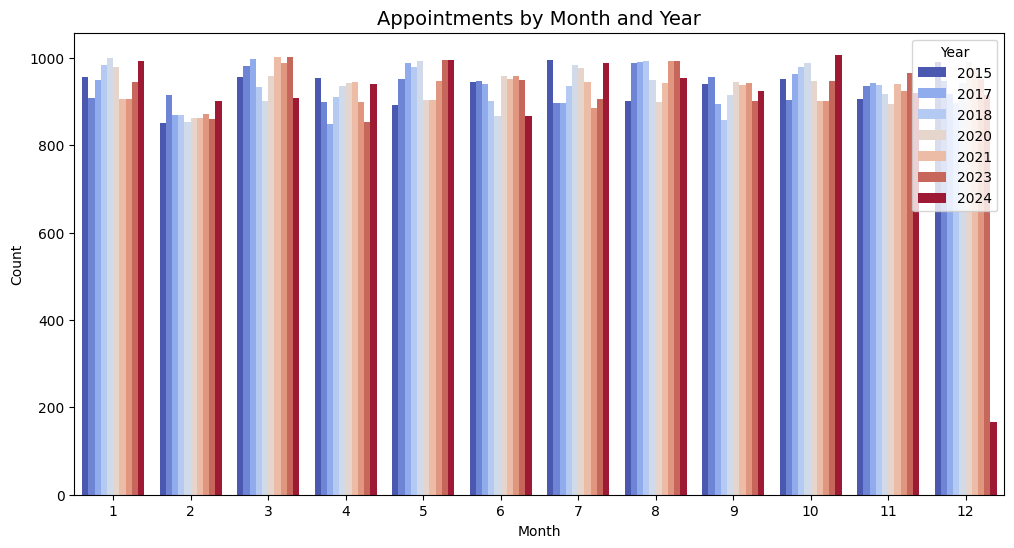

In [ ]:
# Distribution per month per each year
plt.figure(figsize=(12,6))
sns.countplot(x='month', hue='year', data=df_app, palette='coolwarm')
plt.title('Appointments by Month and Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title='Year')
plt.show()

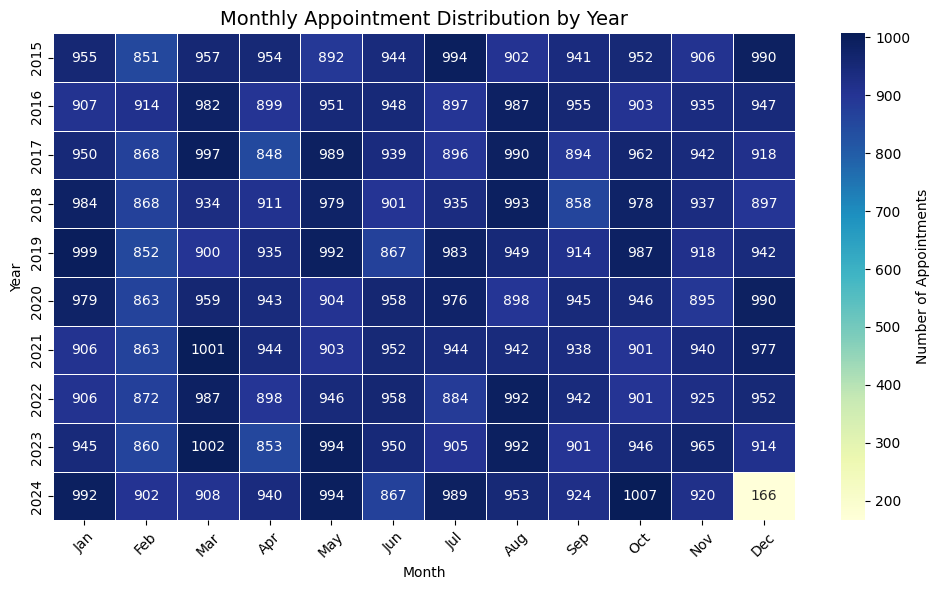

In [ ]:
# The same meaning of distribution per month per year, but with the heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Number of Appointments'}
)

plt.title('Monthly Appointment Distribution by Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

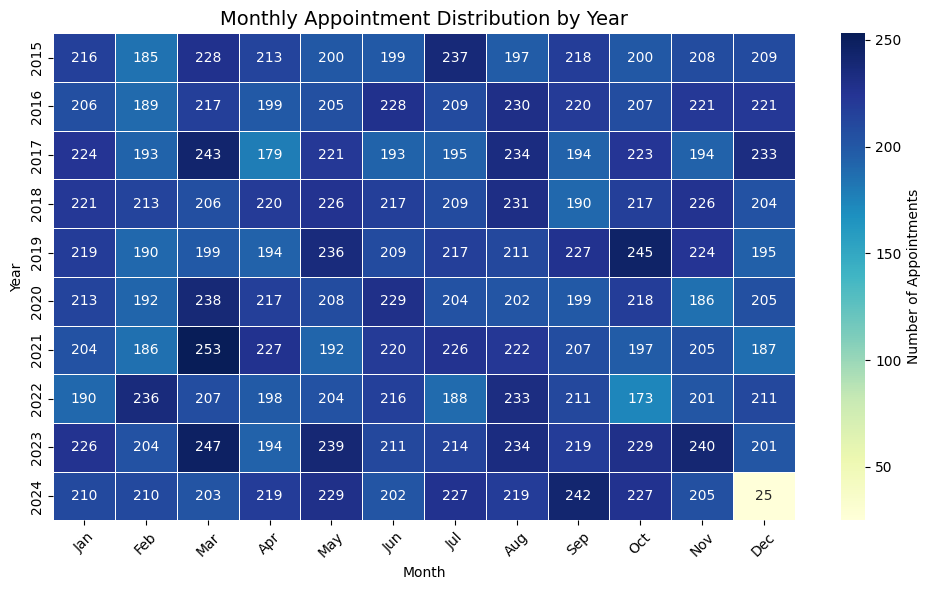

In [ ]:
cancelled_df = df_app[(df_app['status'] != 'attended') & (df_app['status'] != 'scheduled')]

monthly_counts_canc = cancelled_df.groupby(['year', 'month_name']).size().reset_index(name='count')
pivot_df = monthly_counts_canc.pivot(index='year',  columns='month_name', values='count').fillna(0)
month_order_canc = list(calendar.month_abbr)[1:]  # ['Jan', 'Feb', ..., 'Dec']
pivot_df = (
    monthly_counts_canc
    .pivot(index='year', columns='month_name', values='count')
    .reindex(columns=month_order_canc)
    .fillna(0)
)

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Number of Appointments'}
)

plt.title('Monthly Appointment Distribution by Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
merged.info()
# ['scheduling_date', 'appointment_date', 'scheduling_interval', 'age', 'name', 'insurance']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111488 entries, 0 to 111487
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   appointment_id        111488 non-null  int64  
 1   slot_id               111488 non-null  int64  
 2   scheduling_date       111488 non-null  object 
 3   appointment_date      111488 non-null  object 
 4   appointment_time      111488 non-null  object 
 5   scheduling_interval   111488 non-null  int64  
 6   status                111488 non-null  object 
 7   check_in_time         86032 non-null   object 
 8   appointment_duration  86032 non-null   float64
 9   start_time            86032 non-null   object 
 10  end_time              86032 non-null   object 
 11  waiting_time          86032 non-null   float64
 12  patient_id            111488 non-null  int64  
 13  sex_x                 111488 non-null  object 
 14  age                   111488 non-null  int64  
 15  

In [ ]:
df_pat['name'].value_counts()

,count
name,
Jennifer Smith,17
David Johnson,16
James Smith,15
Lisa Johnson,12
James Johnson,12
...,...
Sarah Munoz,1
Gabrielle Davis,1
Gina Moore,1


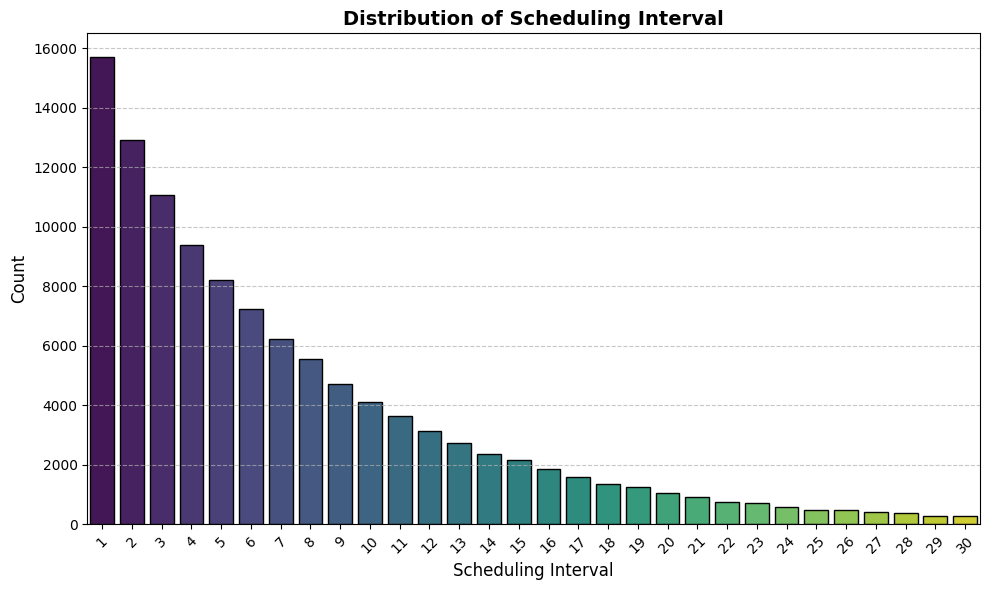

In [ ]:
# Check the scheduling interval distribution
interval_counts = merged['scheduling_interval'].value_counts().sort_index()


plt.figure(figsize=(10, 6))
sns.barplot(x=interval_counts.index, y=interval_counts.values, palette='viridis', edgecolor='black')


plt.title('Distribution of Scheduling Interval', fontsize=14, fontweight='bold')
plt.xlabel('Scheduling Interval', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

We can see skewness in the scheduling interval value, it needs to be reevaluated in order to use as a training feature

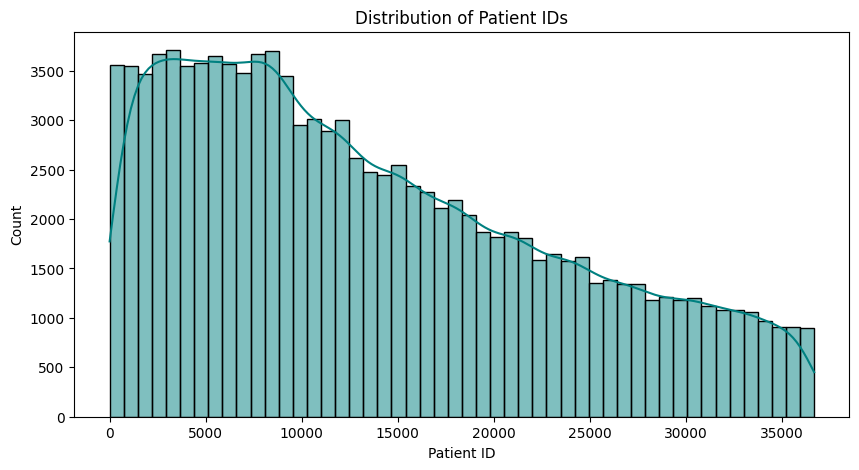

In [ ]:
# Distribution of patient_id
plt.figure(figsize=(10,5))
sns.histplot(merged['patient_id'], bins=50, kde=True, color='teal')
plt.title('Distribution of Patient IDs')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.show()

# 3. Preprocessing


### 3.1. Cleansing

In [ ]:
# Check the missing values in the dataset
merged.isna().sum()

# All important columns fit the criteria

,0
appointment_id,0
slot_id,0
scheduling_date,0
appointment_date,0
appointment_time,0
scheduling_interval,0
status,0
check_in_time,25456
appointment_duration,25456
start_time,25456


### 3.2. Dropping

In [ ]:
# Drop unnecessary columns
df_drop = merged[['scheduling_date', 'appointment_date', 'appointment_time', 'scheduling_interval', 'age', 'sex_x', 'insurance', 'patient_id', 'status']]
# Rename status values
df_drop = df_drop.replace({'status': {'attended': 1, 'cancelled': 0, 'did not attend': 0}})
# Keep only 1 and 0
df_dropped = df_drop[df_drop['status'].isin([0, 1])]
# Rename sex column
df_dropped = df_dropped.rename(columns={'sex_x': 'sex'})

In [ ]:
# Check the final result
df_dropped

,scheduling_date,appointment_date,appointment_time,scheduling_interval,age,sex,insurance,patient_id,status
0,2014-12-28,2015-01-01,08:00:00,4,37,Male,MediSpectra Flux,8285,0
1,2014-12-29,2015-01-01,13:30:00,3,84,Male,CurativeWhale,5972,0
2,2014-12-17,2015-01-01,13:45:00,15,77,Male,Vitalynx Orbit,6472,1
3,2014-12-31,2015-01-01,14:00:00,1,37,Female,Heliospring Vital,5376,1
4,2014-12-26,2015-01-01,14:15:00,6,72,Male,HealthZenotron,8028,0
...,...,...,...,...,...,...,...,...,...
111409,2024-12-01,2024-12-05,11:00:00,4,52,Female,Carebubble Spectrum,26059,0
111413,2024-12-01,2024-12-05,09:30:00,4,70,Female,Mediflora Nexus,9723,0
111416,2024-12-01,2024-12-05,08:15:00,4,18,Female,CuraQuark Alliance,35439,0
111446,2024-12-01,2024-12-10,08:00:00,9,46,Female,HealthZenotron,9788,0


### 3.2. Feature Engineering

In [ ]:
# Use a LabelEncoder for binary sex-column to have 0 and 1 column type
le = LabelEncoder()

In [ ]:
# Encode sex column
df_dropped['sex'] = le.fit_transform(df_dropped['sex'])
# Insurance column will be one-hot encoded because it has several categories, with dropping the original value
df_dropped = pd.get_dummies(df_dropped, columns=['insurance'], drop_first=True)

In [ ]:
# Feature creation function
def build_features(df):

  # The status column should be assigned to integer data type
  df['status'] = df['status'].astype(int)

  # Appointment and scheduling date column change to datetime type
  df['appointment_date'] = pd.to_datetime(df['appointment_date'])
  df['scheduling_date'] = pd.to_datetime(df['scheduling_date'])

  # Extract year, month, day and a weekday from the date, so it can be used in training process
  df['appointment_year'] = df['appointment_date'].dt.year
  df['appointment_month'] = df['appointment_date'].dt.month
  df['appointment_day'] = df['appointment_date'].dt.day
  df['appointment_weekday'] = df['appointment_date'].dt.weekday

  # The same extraction with scheduling date
  df['scheduling_year'] = df['scheduling_date'].dt.year
  df['scheduling_month'] = df['scheduling_date'].dt.month
  df['scheduling_day'] = df['scheduling_date'].dt.day
  df['scheduling_weekday'] = df['scheduling_date'].dt.weekday

  # Create cumulative count of past no-shows per patient
  df = df.sort_values(['patient_id', 'appointment_date'])
  df['no_attend_count'] = (
    df.groupby('patient_id')['status']
    .apply(lambda x: (x == 0).shift().cumsum())
    .reset_index(level=0, drop=True)
  )
  df['no_attend_count'] = df['no_attend_count'].fillna(0).astype(int)

  # Normalize scheduling interval
  df['scheduling_interval_log'] = np.log1p(df['scheduling_interval'])

  # Day-time encoding
  df['appointment_hour'] = pd.to_datetime(df['appointment_time'], errors='coerce').dt.hour
  df['is_morning'] = (df['appointment_hour'] < 12).astype(int)
  df['is_evening'] = (df['appointment_hour'] >= 16).astype(int)



  # Cumulative count of total appointments up to (but not including) this one
  df['total_appointments'] = np.arange(len(df))

  # Cumulative number of attended appointments (status == 1)
  df['attended_so_far'] = (df['status'] == 1).shift().cumsum().fillna(0)

  # Attendance rate = past_attended / total_past_appointments
  df['attendance_rate'] = np.where(
      df['total_appointments'] > 0,
      df['attended_so_far'] / df['total_appointments'],
      0
  )

  # Average scheduling interval (normalized one)
  df['avg_scheduling_interval'] = (
      df['scheduling_interval_log'].shift().expanding().mean().fillna(0)
  )

  # Last known status (previous appointment)
  df['last_status'] = df['status'].shift().fillna(-1)  # -1 = no previous record

  # Age buckets to make a broad age interval and check the influence for the category
  df['age_bucket'] = pd.cut(
    df['age'],
    bins=[0, 20, 30, 45, 60, 75, 102],
    labels=['0–20', '21–30', '31–45', '46–60', '61–75', '76+'],
    right=False
  )

  return df

In [ ]:
df_features = df_dropped.groupby('patient_id', group_keys=False).apply(build_features)
df_features = df_features.drop(columns=['attended_so_far'])


/tmp/ipython-input-3011627344.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_features = df_dropped.groupby('patient_id', group_keys=False).apply(build_features)


In [ ]:
df_features['age_bucket'] = le.fit_transform(df_features['age_bucket'])

In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110901 entries, 0 to 111447
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   scheduling_date                110901 non-null  datetime64[ns]
 1   appointment_date               110901 non-null  datetime64[ns]
 2   appointment_time               110901 non-null  object        
 3   scheduling_interval            110901 non-null  int64         
 4   age                            110901 non-null  int64         
 5   sex                            110901 non-null  int64         
 6   patient_id                     110901 non-null  int64         
 7   status                         110901 non-null  int64         
 8   insurance_Carebubble Spectrum  110901 non-null  bool          
 9   insurance_CuraQuark Alliance   110901 non-null  bool          
 10  insurance_CurativeWhale        110901 non-null  bool          
 11  insur

### 3.4. Correlation check


#### I will drop scheduling year, month, day and weekday and redo the correlation map

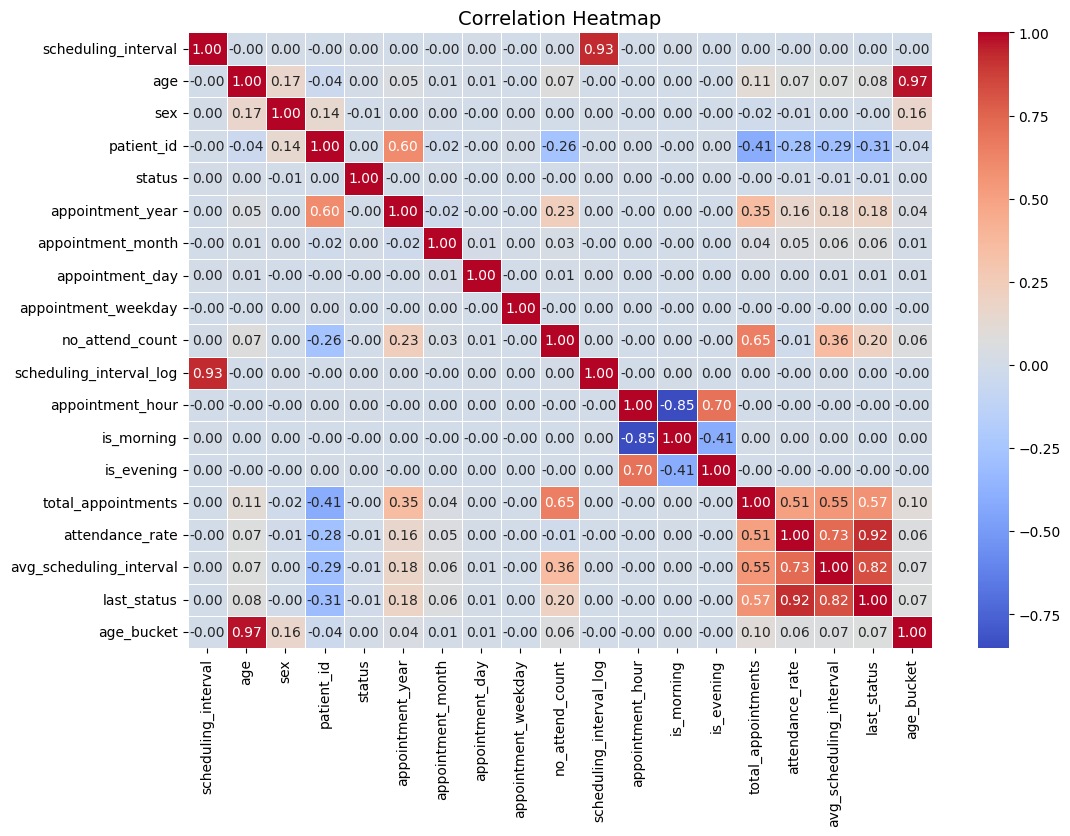

In [ ]:
df_corr = df_features.drop(['scheduling_year',
  'scheduling_month',
  'scheduling_day',
  'scheduling_weekday',
  'scheduling_date',
  'appointment_date',
  'insurance_Carebubble Spectrum',
  'insurance_CuraQuark Alliance',
  'insurance_CurativeWhale',
  'insurance_HealthZenotron',
  'insurance_Heliospring Vital',
  'insurance_MediNimbus',
  'insurance_MediSpectra Flux',
  'insurance_Mediflora Nexus',
  'insurance_QuantumPetal',
  'insurance_Vitalynx Orbit'], axis=1)


# Replot correlation chart
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

Optimal λ (lambda): 0.1163


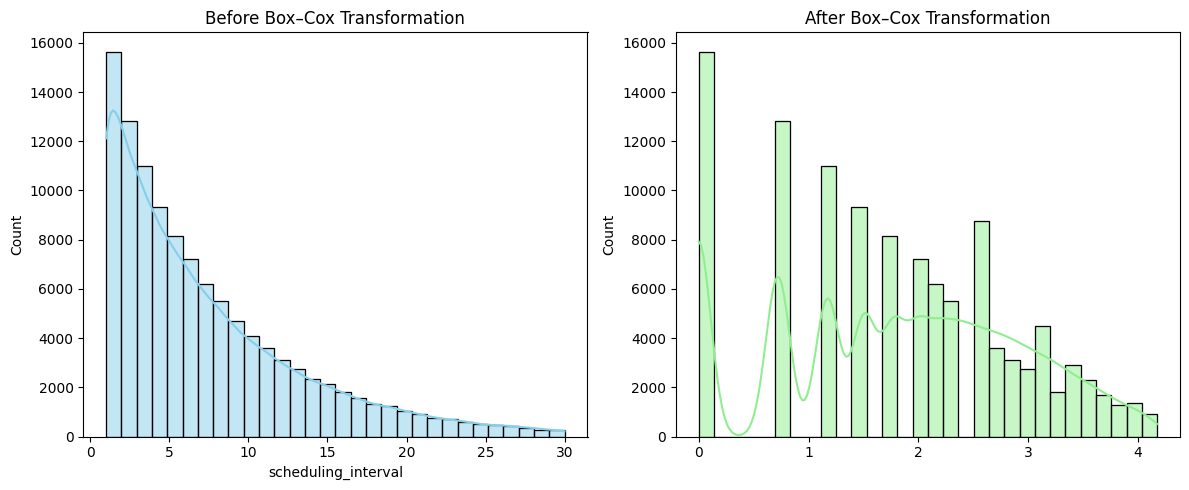

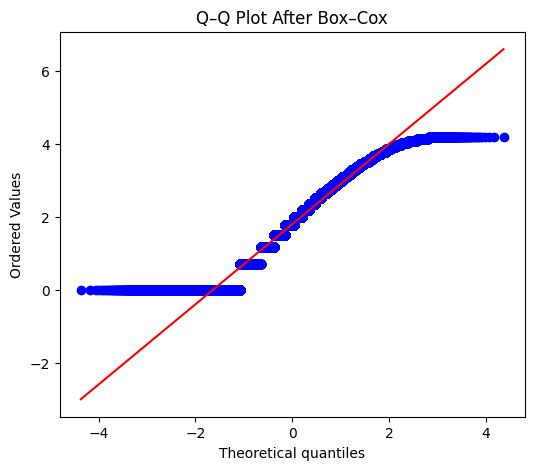

In [ ]:
# Check the differences of normalized and non-normalized scheduling interval

data = df_corr['scheduling_interval'].dropna()

# If any values ≤ 0, shift the data
if (data <= 0).any():
    shift = abs(data.min()) + 1
    data = data + shift
    print(f"Data shifted by +{shift} to make all values positive.")

#  Apply Box–Cox transformation
data_boxcox, lambda_val = boxcox(data)
print(f"Optimal λ (lambda): {lambda_val:.4f}")

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before transformation
sns.histplot(data, bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Before Box–Cox Transformation')

# After transformation
sns.histplot(data_boxcox, bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('After Box–Cox Transformation')

plt.tight_layout()
plt.show()

# Optional — Q–Q Plot to check normality
plt.figure(figsize=(6, 5))
probplot(data_boxcox, dist="norm", plot=plt)
plt.title("Q–Q Plot After Box–Cox")
plt.show()

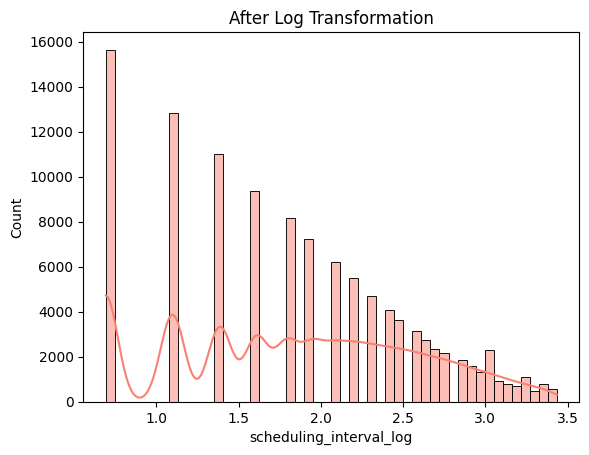

Skewness after log: 0.06316831159554033


In [ ]:
# The logarithmic normalization
sns.histplot(df_corr['scheduling_interval_log'], bins=50, kde=True, color='salmon')
plt.title('After Log Transformation')
plt.show()

print("Skewness after log:", df_corr['scheduling_interval_log'].skew())

In [ ]:
# The final dropping
df_drop = df_features.drop([
  'scheduling_year',
  'scheduling_month',
  'scheduling_day',
  'scheduling_weekday',
  'scheduling_date',
  'appointment_date',
  'scheduling_interval',
  'appointment_time'], axis=1)

### 3.5. Splitting

Several splitting were done to try different option during the training part

In [ ]:
# Split target variable and all other values
X = df_drop.drop('status', axis=1)
y = df_drop['status']

In [ ]:
# Split chronologically, so the training would be on the past data and testing on future
split_idx = int(len(X) * 0.8)

X_train_chr, X_test_chr = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_chr, y_test_chr = y.iloc[:split_idx], y.iloc[split_idx:]

### 3.6. Sampling

#### The data is imbalanced, so we need to sample it before training.

In [ ]:
# Resample (RandomUnderSample) chronologically split dataset
rus = RandomUnderSampler(random_state=42)
X_train_chr_rus, y_train_chr_rus = rus.fit_resample(X_train_chr, y_train_chr)

In [ ]:
"""
SMOTE generates synthetic examples of minority samples
SMOTE-Tomek combines SMOTE (oversampling) and Tomek Links (undersampling)
"""

smote = SMOTE(random_state=42)
smt = SMOTETomek(random_state=42)

# Oversample (SMOTE)
X_train_chr_smote, y_train_chr_smote = smote.fit_resample (X_train_chr, y_train_chr)
# Mixed Sampling method (SMOTE-Tomek)
X_train_chr_smtk, y_train_chr_smtk = smt.fit_resample(X_train_chr, y_train_chr)

### 3.7. Scaling

In [ ]:
"""
# scale data to [0, 1] range
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_res_1)
X_test_scaled = scaler.transform(X_test)
"""
# Standardize features by removing the mean and scaling to unit variance
scaler = StandardScaler()
# Chronologically splitted and underresampled
X_train_scaled_chr_rus = scaler.fit_transform(X_train_chr_rus)
# Chronologically splitted and oversampled
X_train_scaled_chr_smote = scaler.fit_transform(X_train_chr_smote)
X_train_scaled_chr_smtk = scaler.fit_transform(X_train_chr_smtk)
X_test_scaled_chr = scaler.transform(X_test_chr)



# 4. Training

In [ ]:
# Sampled training data dictionary
X_train_scaled_dict = {
    "chr_rus": X_train_scaled_chr_rus,
    "chr_smote": X_train_scaled_chr_smote,
    "chr_smtk": X_train_scaled_chr_smtk
}

y_train_dict = {
    "chr_rus": y_train_chr_rus,
    "chr_smote": y_train_chr_smote,
    "chr_smtk": y_train_chr_smtk
}


## 4.1. RandomForest

In [ ]:
def train_rf_model(sampling_style, X_train_scaled_dict, y_train_dict, X_test_scaled, y_test, X_train):

  X_train_scaled = X_train_scaled_dict[sampling_style]
  y_res = y_train_dict[sampling_style]


  # Initialize the model RandomForest
  model = RandomForestClassifier(
      n_estimators=100,
      max_depth=None,
      class_weight = 'balanced', # to deal with imbalanced dataset for some training data
      random_state=42,
      n_jobs=-1
  )

  # Train the model
  model.fit(X_train_scaled, y_res)

  # Make predictions
  y_pred = model.predict(X_test_scaled)

  # Evaluate performance
  print(" Accuracy:", accuracy_score(y_test, y_pred))
  print("\n Classification Report:\n", classification_report(y_test, y_pred))

  # ROC-AUC curve chart
  # Apply methods to calculate scores for the chart
  y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
  fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
  roc_auc = auc(fpr, tpr)

  # set-up the chart's style
  plt.figure(figsize=(8,6))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC–AUC Curve)')
  plt.legend(loc='lower right')
  plt.grid(alpha=0.3)
  plt.show()


  # --- Precision–Recall (PR–AUC) Curve ---
  precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
  pr_auc = average_precision_score(y_test, y_pred_proba)

  plt.figure(figsize=(8,6))
  plt.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title('Precision–Recall (PR–AUC Curve)')
  plt.legend(loc='lower left')
  plt.grid(alpha=0.3)
  plt.show()

  # Confusion Matrix
  plt.figure(figsize=(6, 4))
  sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
  plt.title("Confusion Matrix")
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.show()

  # Feature Importance
  importances = model.feature_importances_
  feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

  plt.figure(figsize=(8,5))
  sns.barplot(x=feat_imp, y=feat_imp.index, palette='viridis')
  plt.title("Feature Importance (Random Forest)")
  plt.xlabel("Importance Score")
  plt.ylabel("Features")
  plt.tight_layout()
  plt.show()

  return model, feat_imp, roc_auc

### 4.1.1. Random Under Sampling

 Accuracy: 0.5019611379108245

 Classification Report:
               precision    recall  f1-score   support

           0       0.23      0.49      0.31      5131
           1       0.77      0.51      0.61     17050

    accuracy                           0.50     22181
   macro avg       0.50      0.50      0.46     22181
weighted avg       0.64      0.50      0.54     22181



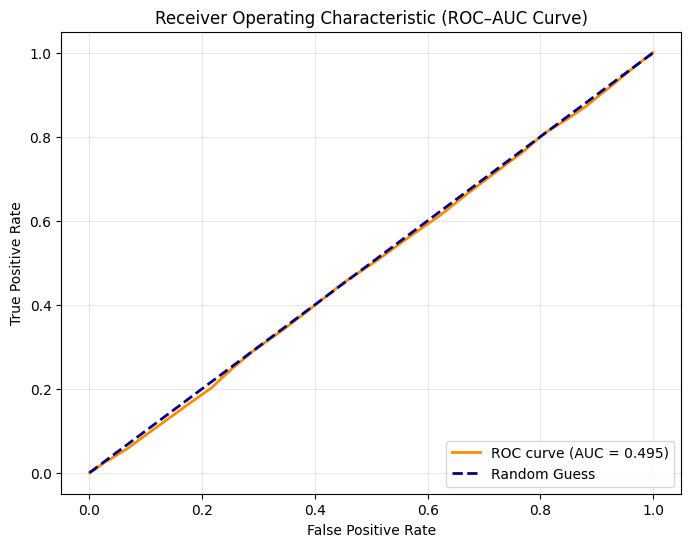

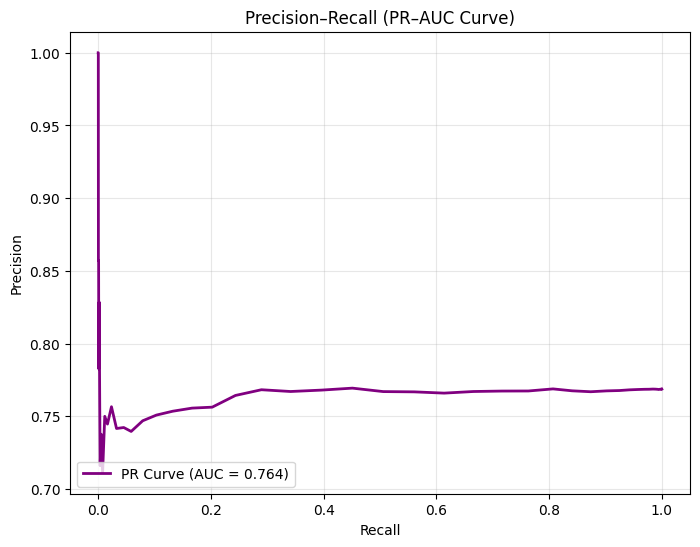

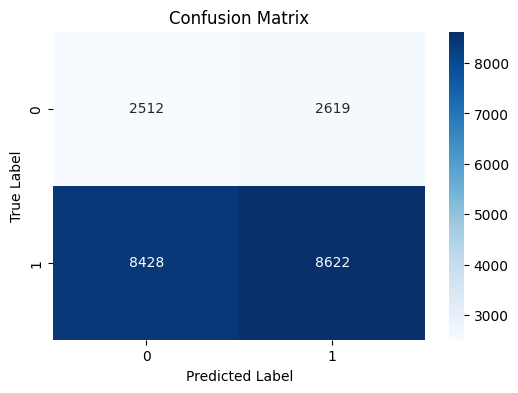

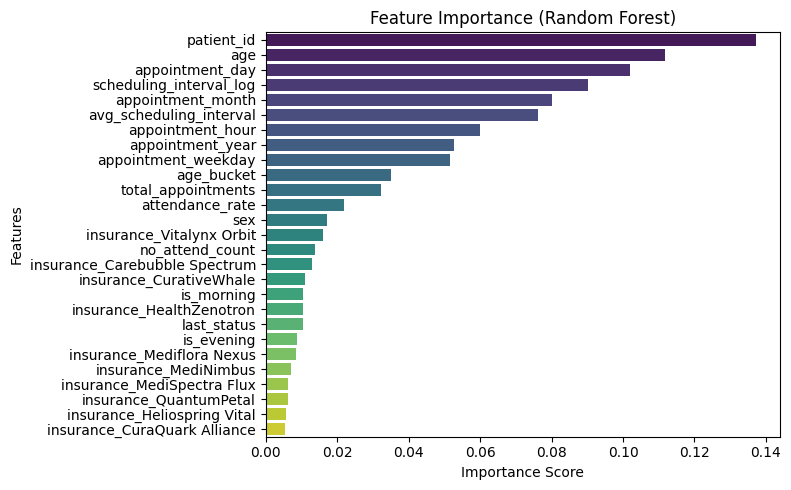

In [ ]:
rf_rus, rf_imp_df_rus, rf_roc_auc_rus = train_rf_model("chr_rus", X_train_scaled_dict, y_train_dict, X_test_scaled_chr, y_test_chr,X_train_chr)

### 4.1.2. SMOTE Sampling

 Accuracy: 0.5106171948965331

 Classification Report:
               precision    recall  f1-score   support

           0       0.23      0.46      0.30      5131
           1       0.76      0.53      0.62     17050

    accuracy                           0.51     22181
   macro avg       0.49      0.49      0.46     22181
weighted avg       0.64      0.51      0.55     22181



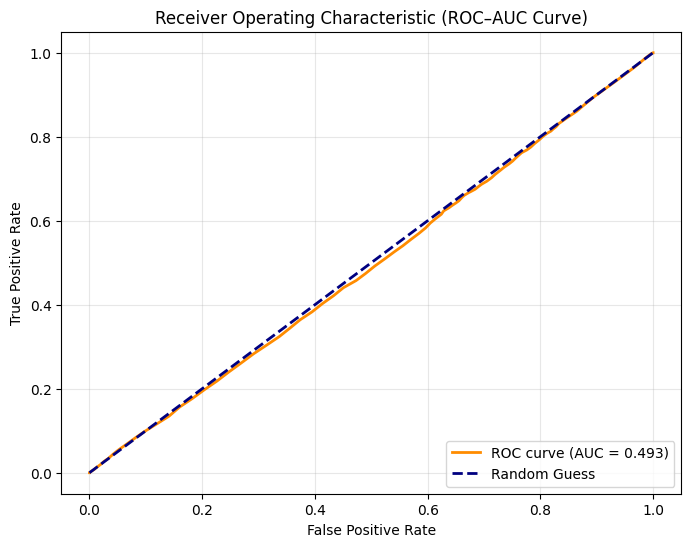

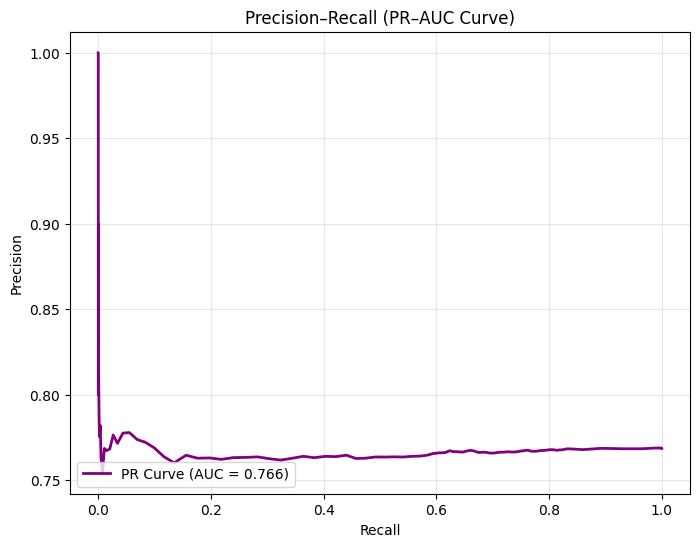

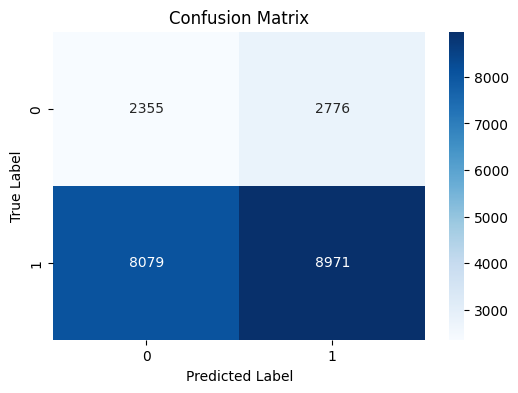

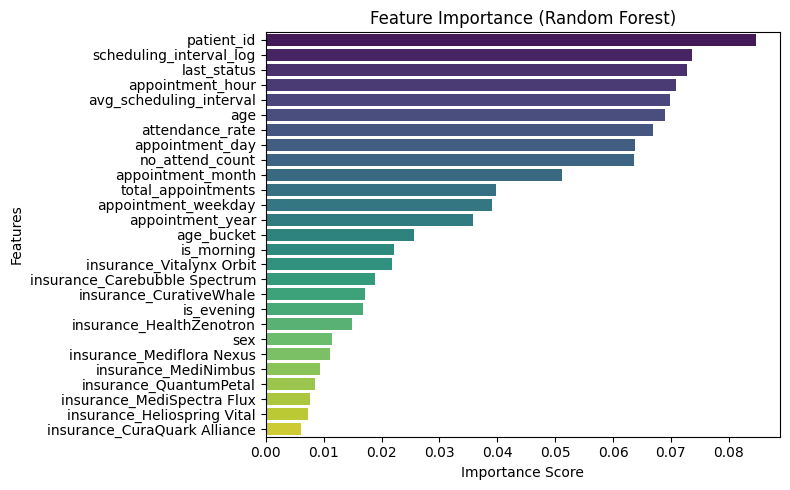

In [ ]:
rf_smote, rf_imp_df_smote, rf_roc_auc_smote = train_rf_model("chr_smote", X_train_scaled_dict, y_train_dict, X_test_scaled_chr, y_test_chr, X_train_chr)

### 4.1.3. SMOTE-Tomek Sampling

 Accuracy: 0.7549253865921284

 Classification Report:
               precision    recall  f1-score   support

           0       0.23      0.02      0.04      5131
           1       0.77      0.97      0.86     17050

    accuracy                           0.75     22181
   macro avg       0.50      0.50      0.45     22181
weighted avg       0.64      0.75      0.67     22181



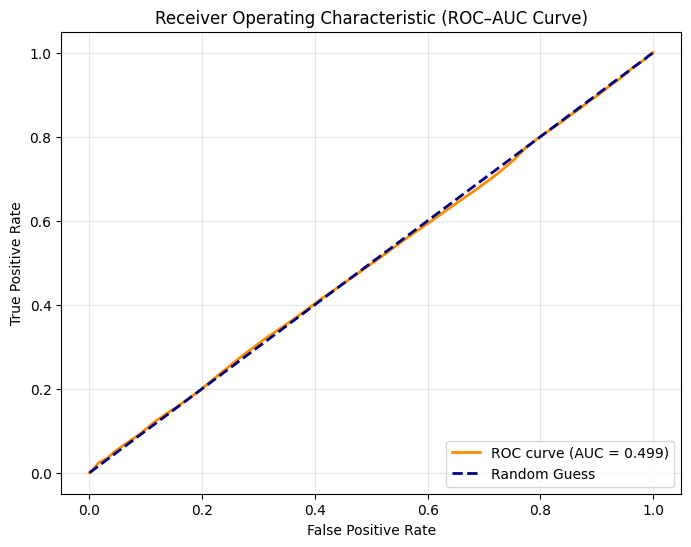

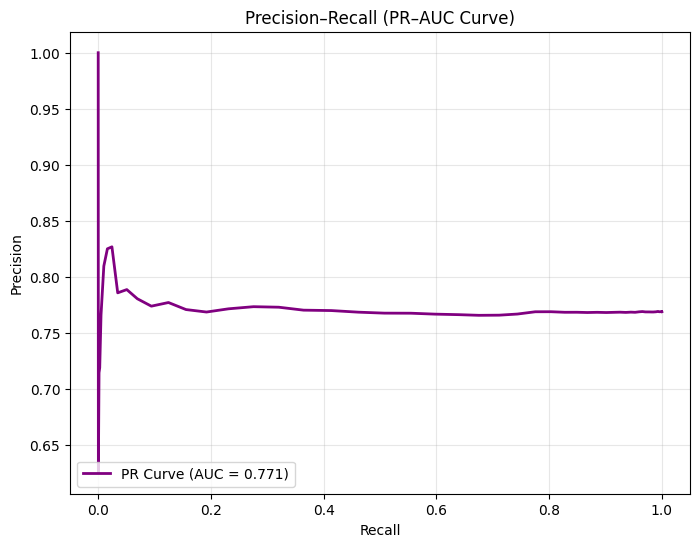

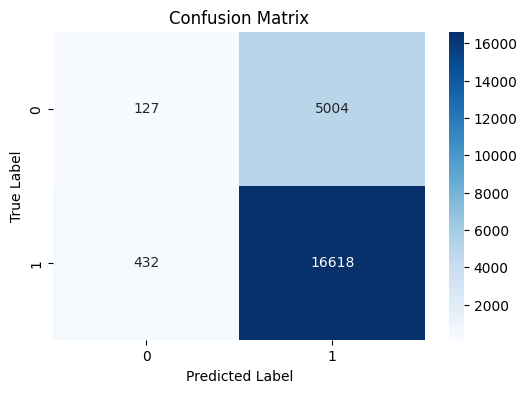

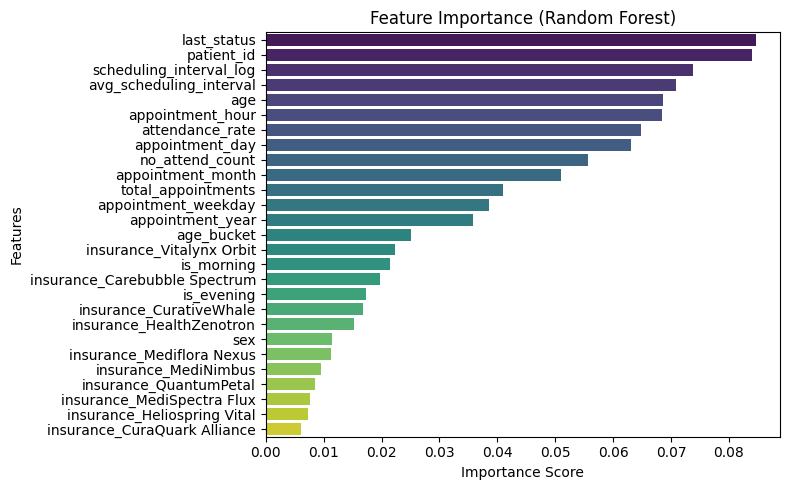

In [ ]:
rf_smtk, rf_imp_df_smtk, rf_roc_auc_smtk = train_rf_model("chr_smtk", X_train_scaled_dict, y_train_dict, X_test_scaled_chr, y_test_chr, X_train_chr)

## 4.2. XGBoost

In [ ]:

def train_xgb_model(sampling_style, X_train_scaled_dict, y_train_dict, X_test_scaled, y_test, X_train):

  """
  Train and evaluate a XGBoost model with different sampling techniques.
  sampling_style: ['rus', 'smote', 'smtk']
  """

  print(f"\n==============================")
  print(f"Training XGBoost with {sampling_style.upper()} sampling")
  print(f"==============================\n")

  # 1. Extract train data
  X_train_scaled = X_train_scaled_dict[sampling_style]
  y_res = y_train_dict[sampling_style]

  # =============================
  # 2. class imbalance ratio
  # =============================
  neg, pos = np.bincount(y_res)
  scale_pos_weight = neg / pos
  print(f"Imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

  # =============================
  # 3. Train XGBoost
  # =============================
  model = XGBClassifier(
      n_estimators=300,
      max_depth=5,
      learning_rate=0.05,
      subsample=0.8,
      colsample_bytree=0.8,
      scale_pos_weight=scale_pos_weight,
      random_state=42,
      use_label_encoder=False,
      eval_metric='logloss'
  )

  model.fit(X_train_scaled, y_res)

  # =============================
  # 4. Predictions and Metrics
  # =============================
  y_pred = model.predict(X_test_scaled)
  y_prob = model.predict_proba(X_test_scaled)[:, 1]

  print("Classification Report:")
  print(classification_report(y_test, y_pred))

  # =============================
  # 4. Confusion Matrix
  # =============================
  plt.figure(figsize=(5,4))
  sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  # =============================
  # 5. ROC–AUC Curve
  # =============================
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)
  roc_auc = auc(fpr, tpr)

  plt.figure(figsize=(6,5))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC–AUC Curve for XGBoost')
  plt.legend(loc='lower right')
  plt.show()

  # =============================
  # 6. PR-AUC Curve
  # =============================
  precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
  pr_auc = average_precision_score(y_test, y_prob)

  plt.figure(figsize=(8,6))
  plt.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title('Precision–Recall (PR–AUC Curve)')
  plt.legend(loc='lower left')
  plt.grid(alpha=0.3)
  plt.show()


  # =============================
  # 7. Feature Importance
  # =============================
  # Get feature importance scores
  importance_dict = model.get_booster().get_score(importance_type='gain')

  # Create a mapping from f0 → actual column name
  feature_map = {f"f{i}": col for i, col in enumerate(X_train.columns)}

  # Replace names in the importance dictionary
  importance_df = pd.DataFrame({
      'Feature': [feature_map.get(f, f) for f in importance_dict.keys()],
      'Importance': importance_dict.values()
  }).sort_values(by='Importance', ascending=False).head(15)

  # Plot
  plt.figure(figsize=(10,6))
  plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
  plt.xlabel('Gain')
  plt.ylabel('Features')
  plt.title('Top 15 Feature Importances (Gain)', fontsize=14)
  plt.gca().invert_yaxis()
  plt.tight_layout()
  plt.show()


  return model, importance_df, roc_auc

### 4.2.1. Random Under Sampling


Training XGBoost with CHR_RUS sampling

Imbalance ratio (scale_pos_weight): 1.00
Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.39      0.29      5131
           1       0.77      0.61      0.68     17050

    accuracy                           0.56     22181
   macro avg       0.50      0.50      0.48     22181
weighted avg       0.64      0.56      0.59     22181



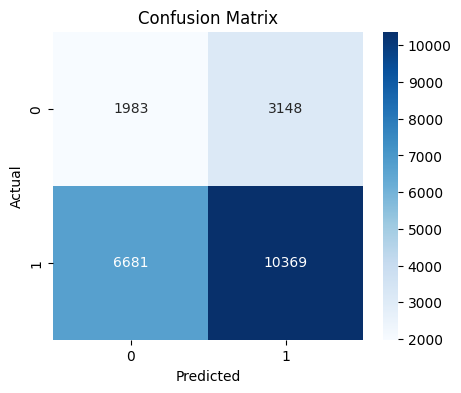

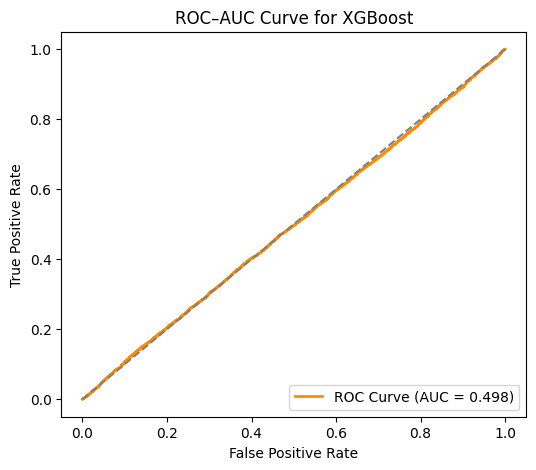

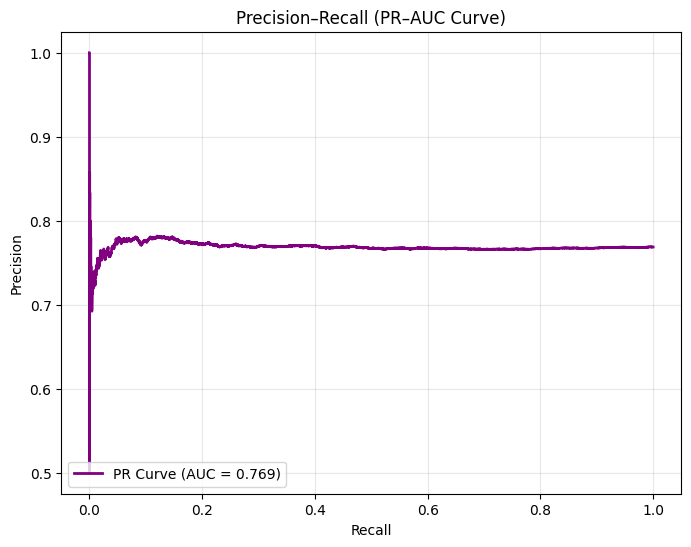

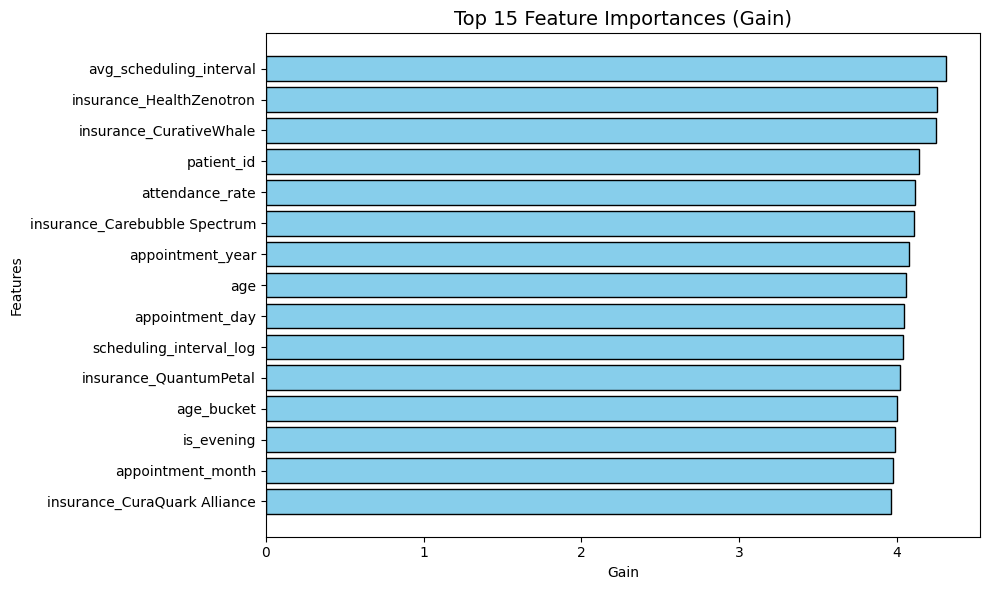

In [ ]:
xgb_rus, xgb_imp_df_rus, xgb_roc_auc_rus = train_xgb_model("chr_rus", X_train_scaled_dict, y_train_dict, X_test_scaled_chr, y_test_chr, X_train_chr)

### 4.2.2. SMOTE-Sampling


Training XGBoost with CHR_SMOTE sampling

Imbalance ratio (scale_pos_weight): 1.00
Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.74      0.35      5131
           1       0.77      0.26      0.38     17050

    accuracy                           0.37     22181
   macro avg       0.50      0.50      0.37     22181
weighted avg       0.64      0.37      0.38     22181



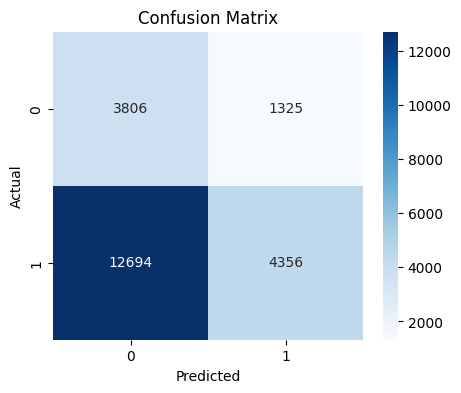

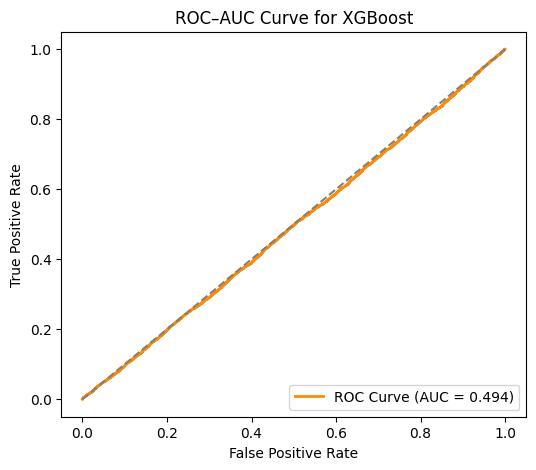

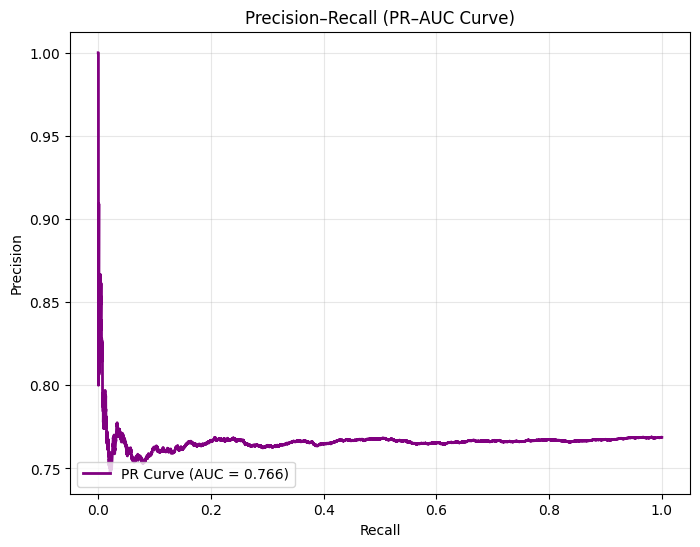

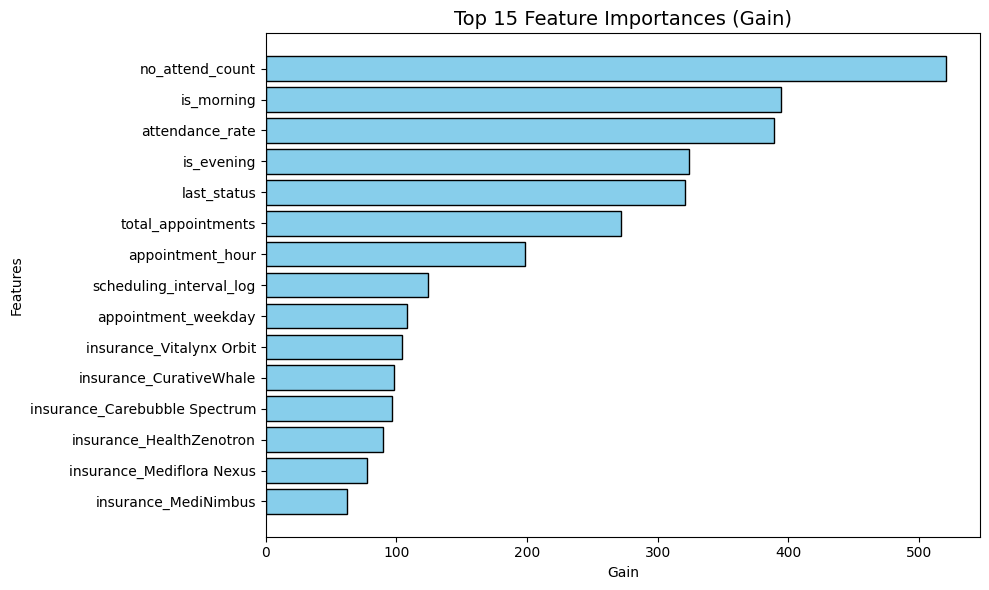

In [ ]:
xgb_smote, xgb_imp_df_smote, xgb_roc_auc_smote = train_xgb_model("chr_smote", X_train_scaled_dict, y_train_dict, X_test_scaled_chr, y_test_chr, X_train_chr)

### 4.2.3. SMOTE-Tomek Sampling


Training XGBoost with CHR_SMTK sampling

Imbalance ratio (scale_pos_weight): 1.00
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5131
           1       0.77      1.00      0.87     17050

    accuracy                           0.77     22181
   macro avg       0.38      0.50      0.43     22181
weighted avg       0.59      0.77      0.67     22181



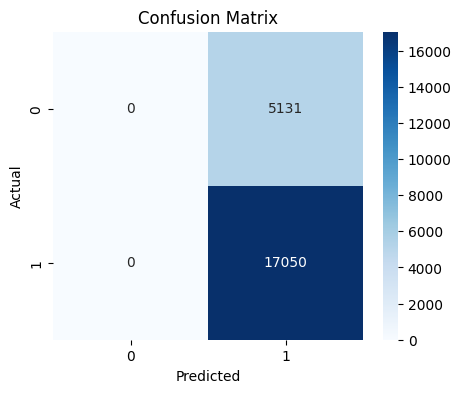

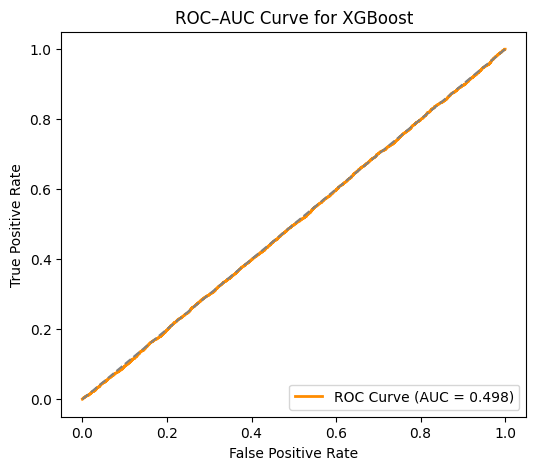

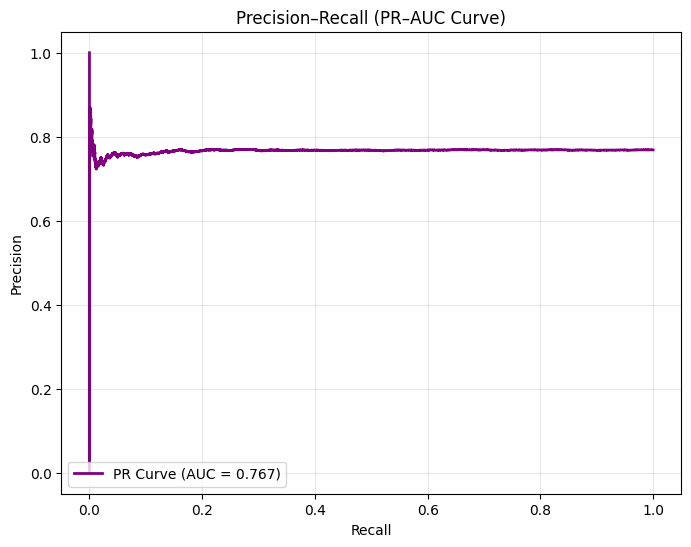

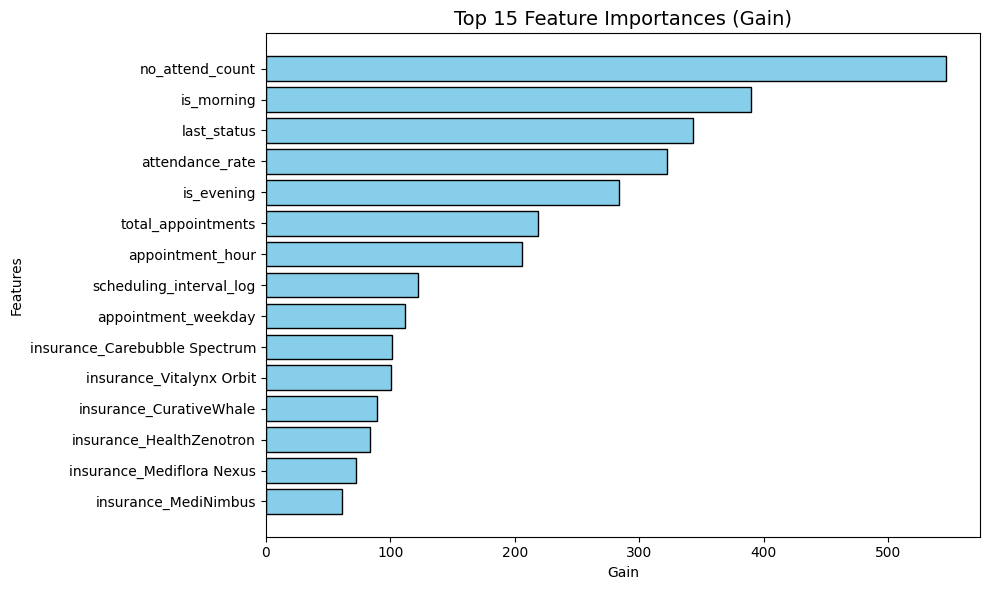

In [ ]:
xgb_smtk, xgb_imp_df_smtk, xgb_roc_auc_smtk = train_xgb_model("chr_smtk", X_train_scaled_dict, y_train_dict, X_test_scaled_chr, y_test_chr, X_train_chr)

## 4.3. LightGBM

In [ ]:


# LGBM-model's function

def train_lgbm_model(sampling_style, X_train_scaled_dict, y_train_dict, X_test_scaled, y_test, X_train):
    """
    Train and evaluate a LightGBM model for a given sampling style.
    sampling_style: one of ['rus', 'smote', 'smtk']
    """
    print(f"\n==============================")
    print(f"Training LightGBM on {sampling_style.upper()} dataset")
    print(f"==============================")

    # 1. Extract train data for the chosen sampling style
    X_train_scaled = X_train_scaled_dict[sampling_style]
    y_res = y_train_dict[sampling_style]

    # 2. Compute class imbalance ratio
    neg, pos = np.bincount(y_res)
    scale_pos_weight = neg / pos
    print(f"Imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # 3. Initialize model
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight=None,
        random_state=42,
        objective='binary',
        n_jobs=-1
    )

    # 4. Train
    model.fit(X_train_scaled, y_res)

    # 5. Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # 6. Metrics
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix – LightGBM ({sampling_style.upper()})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC–AUC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC–AUC Curve (LightGBM – {sampling_style.upper()})')
    plt.legend(loc='lower right')
    plt.show()


    # PR-AUC Curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall (PR–AUC Curve)')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.show()


    # Feature Importance
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='lightgreen', edgecolor='black')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.title(f'Top 15 Feature Importances – LightGBM ({sampling_style.upper()})', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # 7. Save model dynamically by name
    globals()[f"lgb_{sampling_style}"] = model
    print(f"\n✅ Model saved as variable: lgb_{sampling_style}")

    return model, importance_df, roc_auc




### 4.3.1. Random Under Sampling


Training LightGBM on CHR_RUS dataset
Imbalance ratio (scale_pos_weight): 1.00
[LightGBM] [Info] Number of positive: 19738, number of negative: 19738
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 799
[LightGBM] [Info] Number of data points in the train set: 39476, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

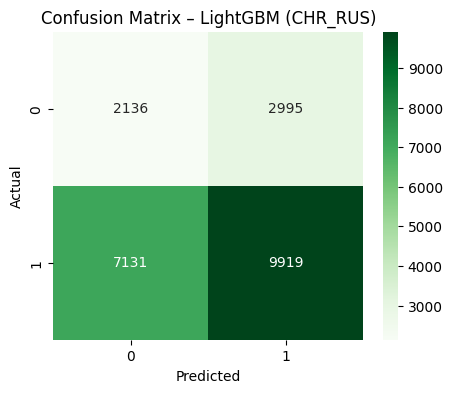

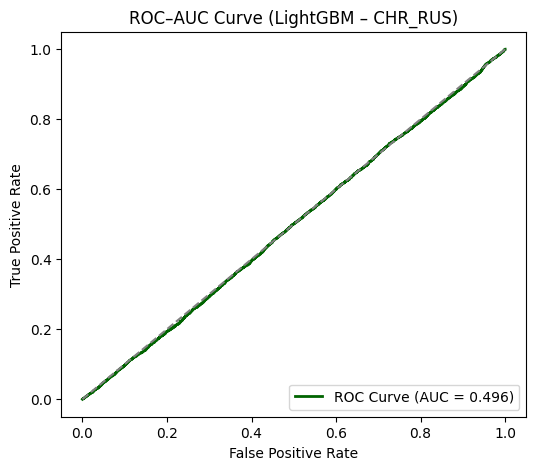

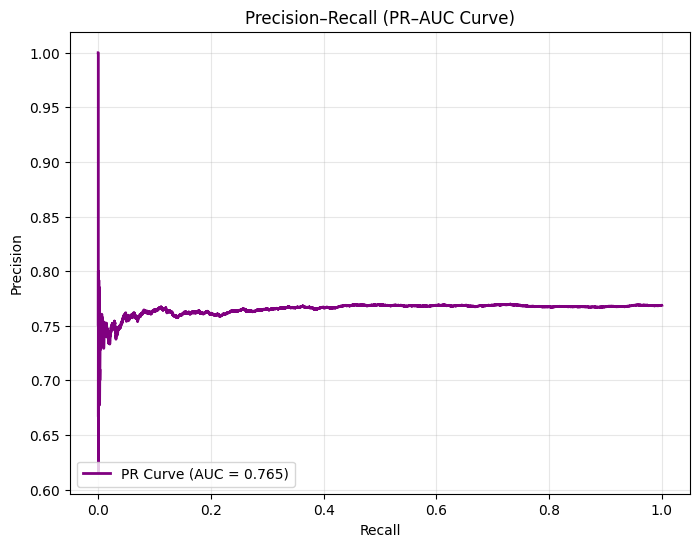

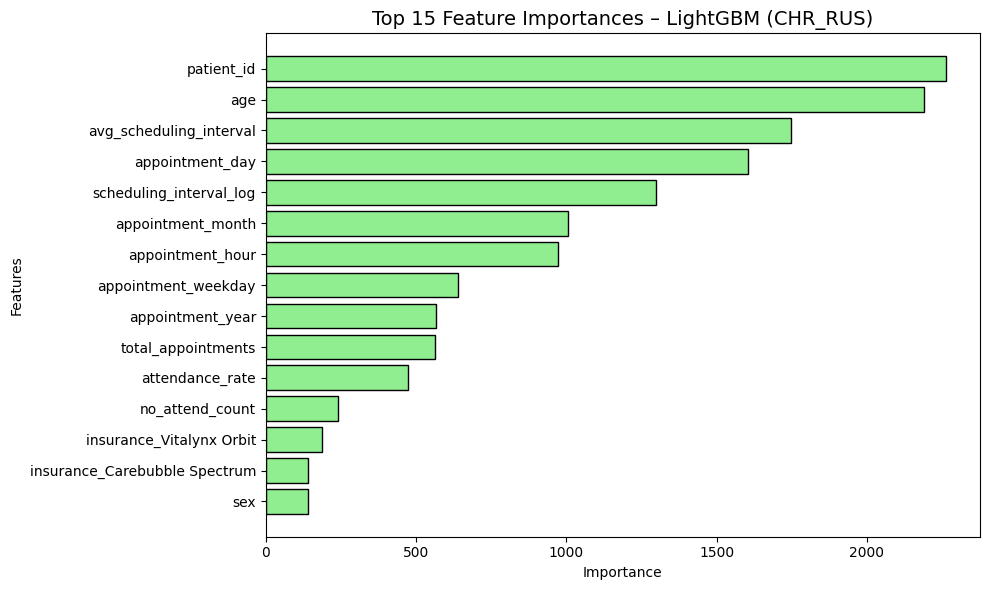


✅ Model saved as variable: lgb_chr_rus


In [ ]:
lgbm_rus, imp_df_lgb_rus, auc_score_lgb_rus = train_lgbm_model(
    'chr_rus',
    X_train_scaled_dict,
    y_train_dict,
    X_test_scaled_chr,
    y_test_chr,
    X_train_chr
)

### 4.3.2. SMOTE Sampling


Training LightGBM on CHR_SMOTE dataset
Imbalance ratio (scale_pos_weight): 1.00
[LightGBM] [Info] Number of positive: 68982, number of negative: 68982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 137964, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.94      0.37      5131
           1       0.74      0.05      0.10     17050

    accuracy                           0.26     22181
   macro avg       0.49      0.50      0.23     22181
weighted avg       0.62      0.26      0.16     22181



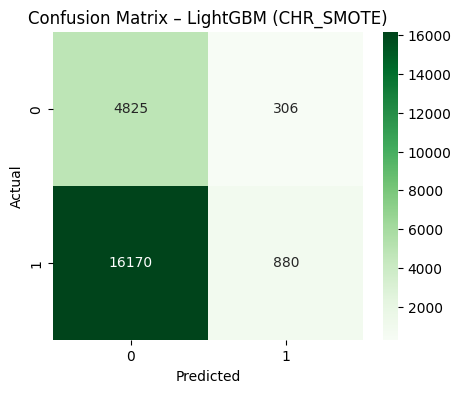

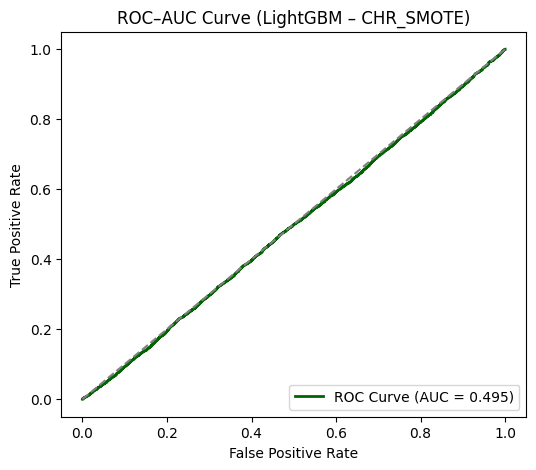

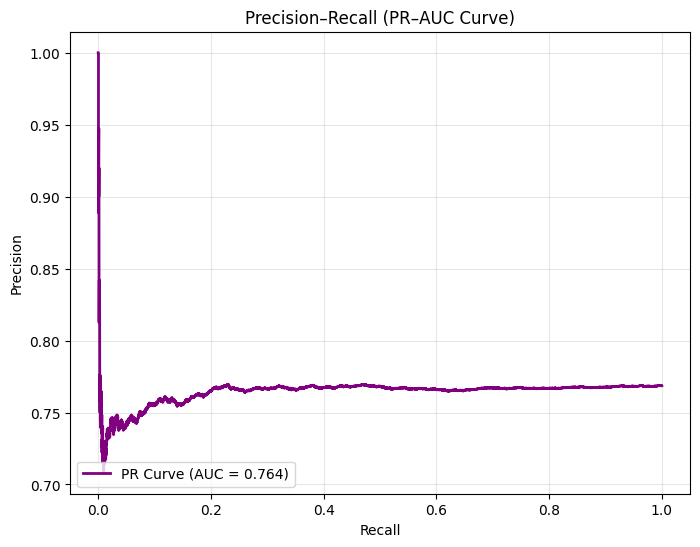

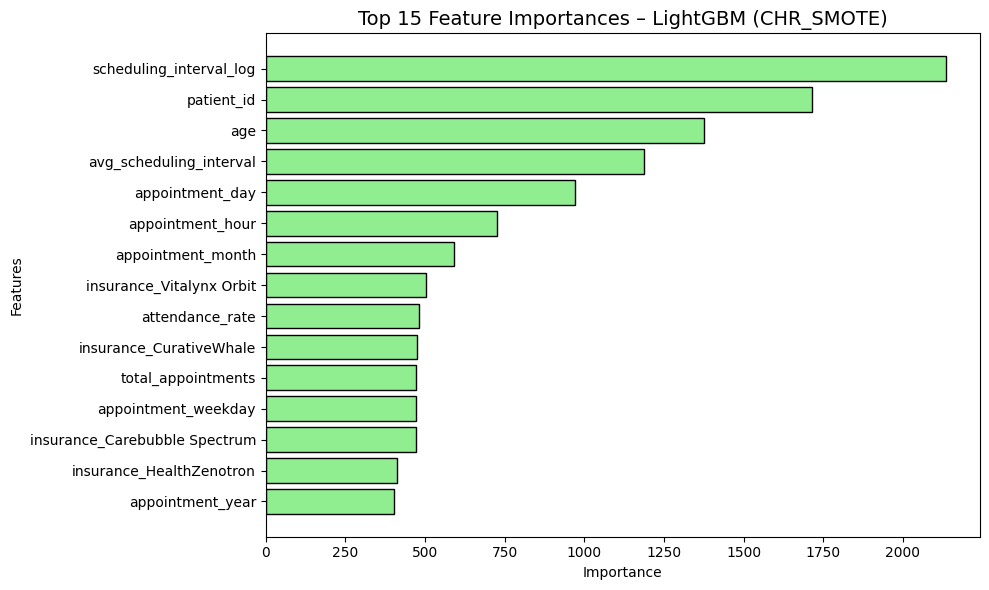


✅ Model saved as variable: lgb_chr_smote


In [ ]:
lgbm_smote, imp_df_lgb_smote, auc_score_lgb_smote = train_lgbm_model(
    'chr_smote',
    X_train_scaled_dict,
    y_train_dict,
    X_test_scaled_chr,
    y_test_chr,
    X_train_chr
)

### 4.3.3. SMOTE-Tomek Sampling


Training LightGBM on CHR_SMTK dataset
Imbalance ratio (scale_pos_weight): 1.00
[LightGBM] [Info] Number of positive: 66871, number of negative: 66871
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 133742, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.00      0.00      5131
           1       0.77      1.00      0.87     17050

    accuracy                           0.77     22181
   macro avg       0.53      0.50      0.44     22181
weighted avg       0.66      0.77      0.67     22181



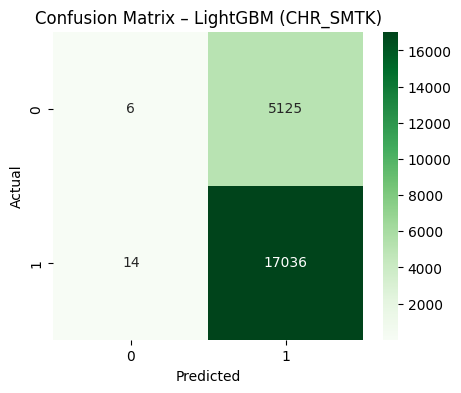

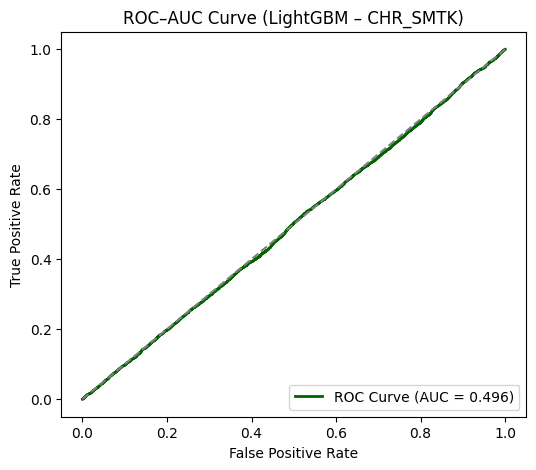

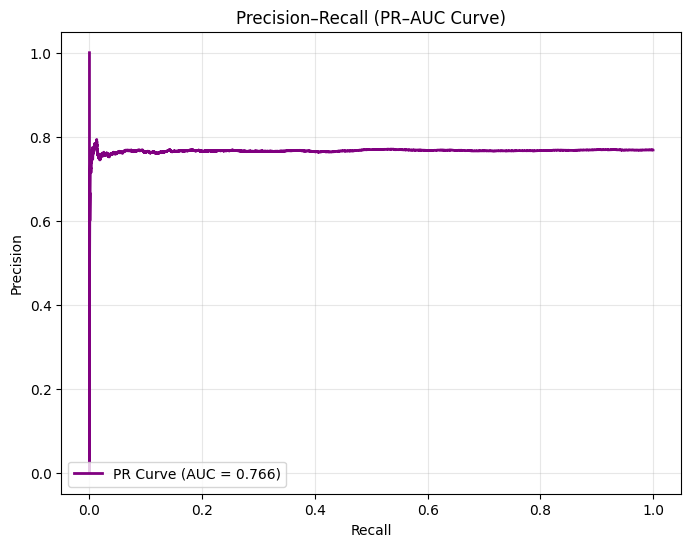

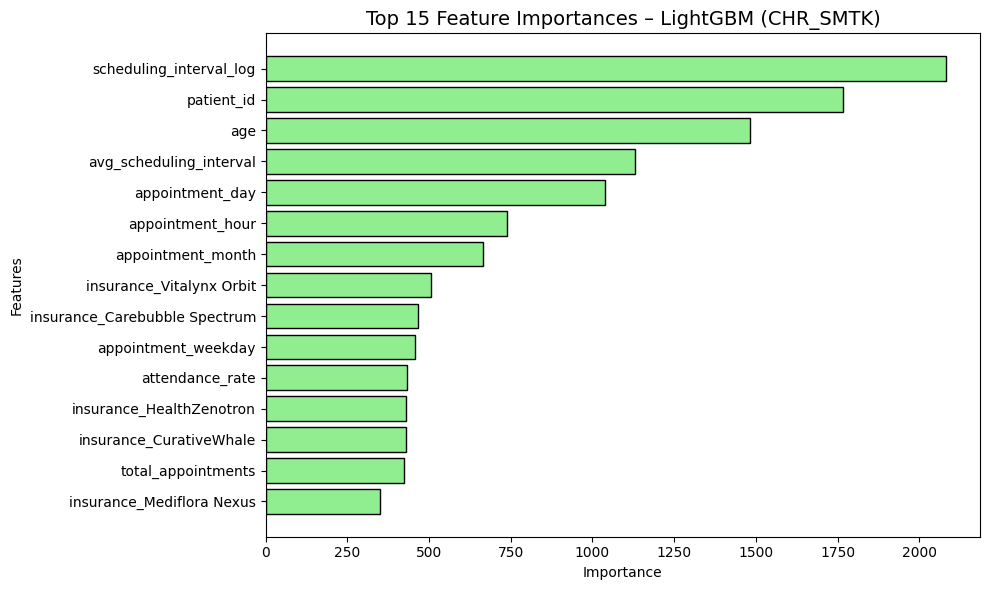


✅ Model saved as variable: lgb_chr_smtk


In [ ]:
lgbm_smtk, imp_df_lgb_smtk, auc_score_lgb_smtk = train_lgbm_model(
    'chr_smtk',
    X_train_scaled_dict,
    y_train_dict,
    X_test_scaled_chr,
    y_test_chr,
    X_train_chr
)

## 4.4. CatBoost

In [ ]:
def train_catboost_model(sampling_style, X_train_scaled_dict, y_train_dict, X_test_scaled, y_test, X_train):
  """
  Train and evaluate a CatBoost model for a given sampling style.
  sampling_style: one of ['chr_rus', 'chr_smote', 'chr_smtk']
  """


  # =============================
  # 1. Class imbalance ratio
  # =============================
  neg, pos = np.bincount(y_train_dict[sampling_style])
  scale_pos_weight = neg / pos
  print(f"Imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

  # =============================
  # 2. Train CatBoost
  # =============================
  model = CatBoostClassifier(
      iterations=500,
      learning_rate=0.05,
      depth=7,
      loss_function='Logloss',
      eval_metric='AUC',
      scale_pos_weight=scale_pos_weight,
      random_seed=42,
      verbose=False
  )

  model.fit(X_train_scaled_dict[sampling_style], y_train_dict[sampling_style])

  # =============================
  # 3. Predictions and Metrics
  # =============================
  y_pred = model.predict(X_test_scaled)
  y_prob = model.predict_proba(X_test_scaled)[:, 1]

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))

  # =============================
  # 4. Confusion Matrix
  # =============================
  plt.figure(figsize=(5, 4))
  sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
  plt.title('Confusion Matrix – CatBoost')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  # =============================
  # 5. ROC–AUC Curve
  # =============================
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)
  roc_auc = auc(fpr, tpr)

  plt.figure(figsize=(6, 5))
  plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
  plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC–AUC Curve (CatBoost)')
  plt.legend(loc='lower right')
  plt.show()

  # 6. PR-AUC Curve
  precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
  pr_auc = average_precision_score(y_test, y_prob)

  plt.figure(figsize=(8,6))
  plt.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title('Precision–Recall (PR–AUC Curve)')
  plt.legend(loc='lower left')
  plt.grid(alpha=0.3)
  plt.show()

  # =============================
  # 7. Feature Importance
  # =============================
  importance_df = pd.DataFrame({
      'Feature': X_train.columns,
      'Importance': model.get_feature_importance()
  }).sort_values(by='Importance', ascending=False).head(15)

  plt.figure(figsize=(10, 6))
  plt.barh(importance_df['Feature'], importance_df['Importance'], color='mediumorchid', edgecolor='black')
  plt.xlabel('Importance')
  plt.ylabel('Features')
  plt.title('Top 15 Feature Importances (CatBoost)', fontsize=14)
  plt.gca().invert_yaxis()
  plt.tight_layout()
  plt.show()

  return model, importance_df, roc_auc

### 4.4.1. Random Under Sampling

Imbalance ratio (scale_pos_weight): 1.00

Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.40      0.30      5131
           1       0.77      0.61      0.68     17050

    accuracy                           0.56     22181
   macro avg       0.50      0.50      0.49     22181
weighted avg       0.65      0.56      0.59     22181



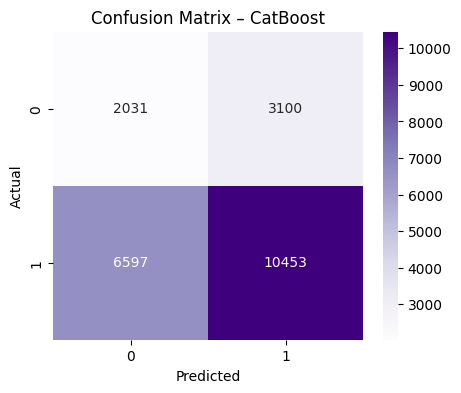

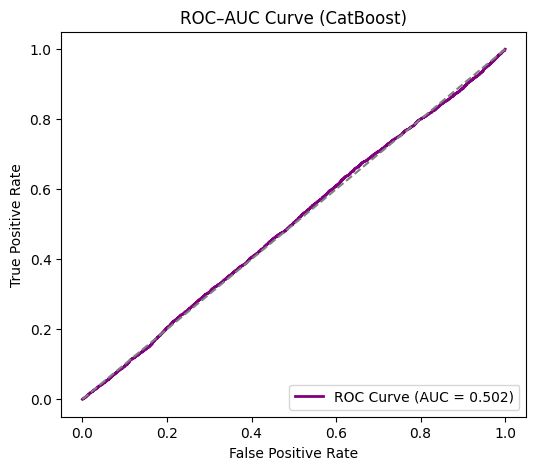

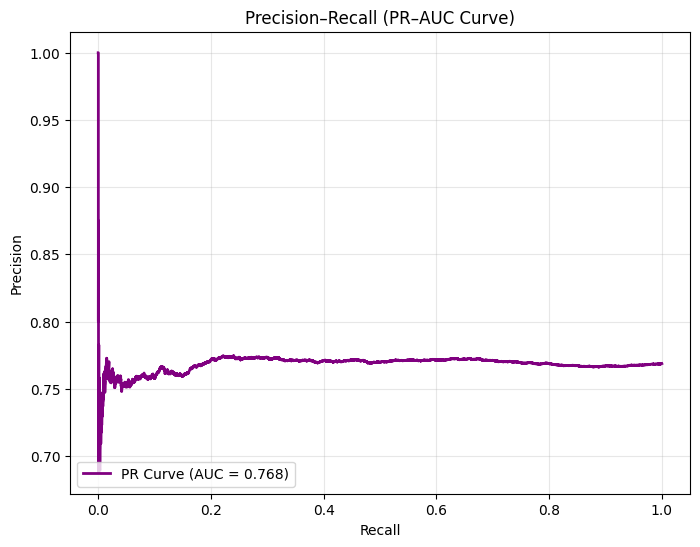

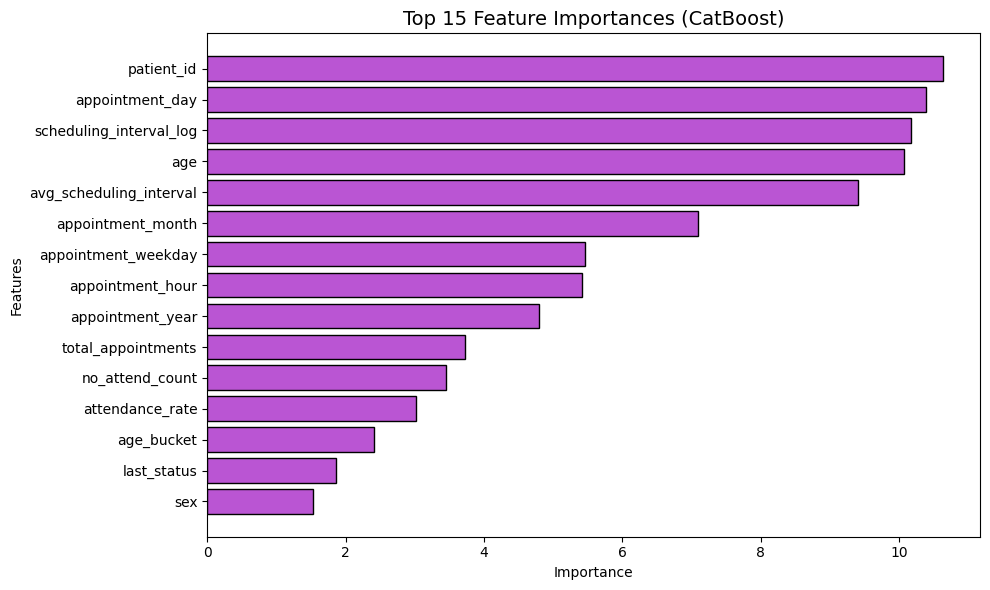

In [ ]:
cat_rus, cat_im_df_rus, cat_auc_rus = train_catboost_model(
    'chr_rus',
    X_train_scaled_dict,
    y_train_dict,
    X_test_scaled_chr,
    y_test_chr,
    X_train_chr
)

### 4.4.2. SMOTE Sampling

Imbalance ratio (scale_pos_weight): 1.00

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.80      0.35      5131
           1       0.76      0.19      0.30     17050

    accuracy                           0.33     22181
   macro avg       0.49      0.49      0.33     22181
weighted avg       0.63      0.33      0.31     22181



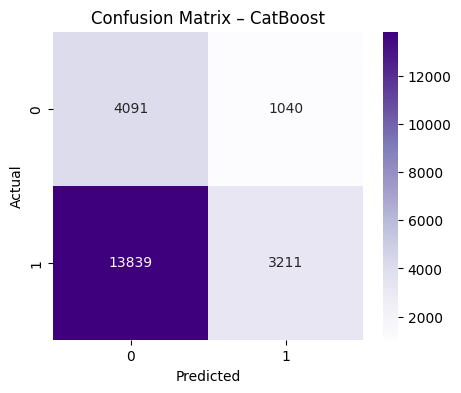

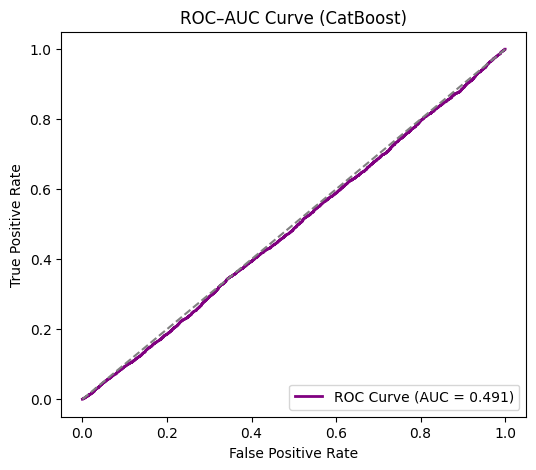

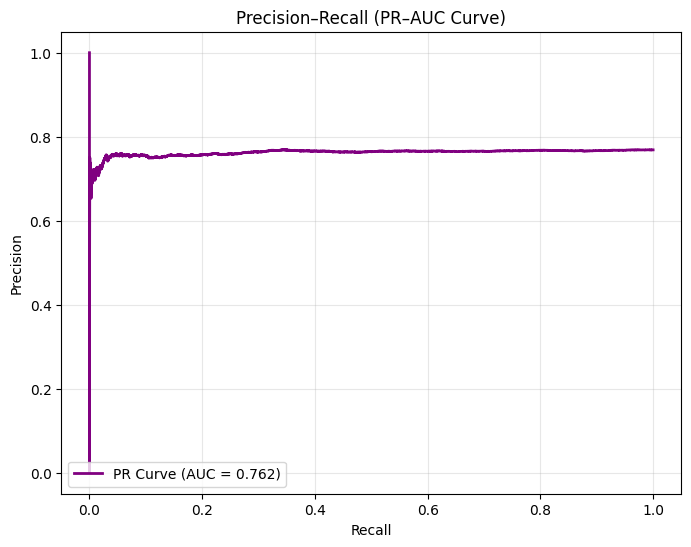

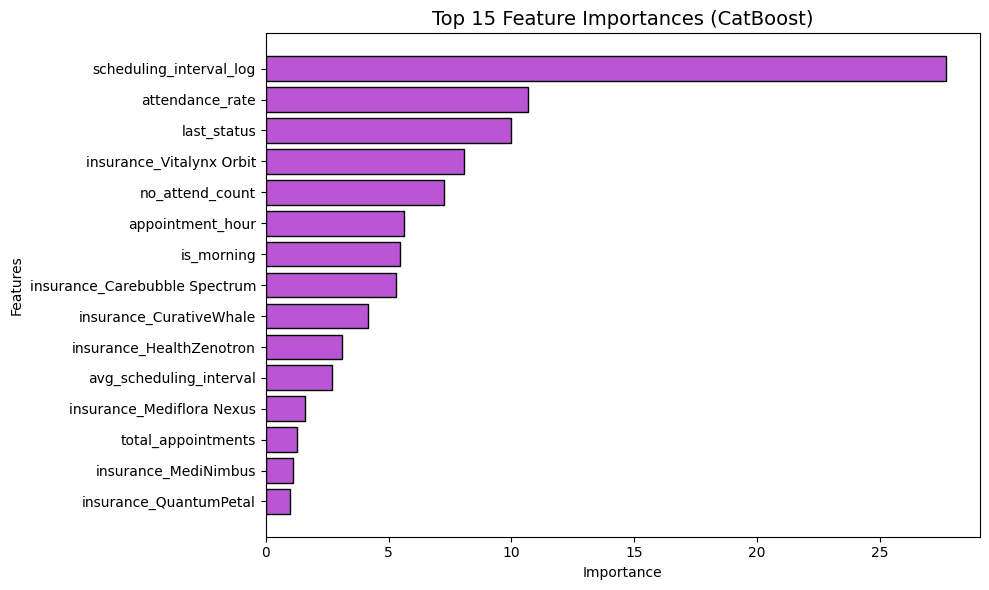

In [ ]:
cat_smote, cat_imp_df_smote, cat_auc_smote = train_catboost_model(
    'chr_smote',
    X_train_scaled_dict,
    y_train_dict,
    X_test_scaled_chr,
    y_test_chr,
    X_train_chr)

### 4.4.3. SMOTE-Tomek Sampling

Imbalance ratio (scale_pos_weight): 1.00

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5131
           1       0.77      1.00      0.87     17050

    accuracy                           0.77     22181
   macro avg       0.38      0.50      0.43     22181
weighted avg       0.59      0.77      0.67     22181



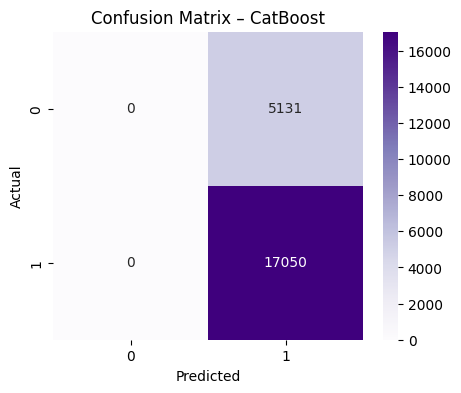

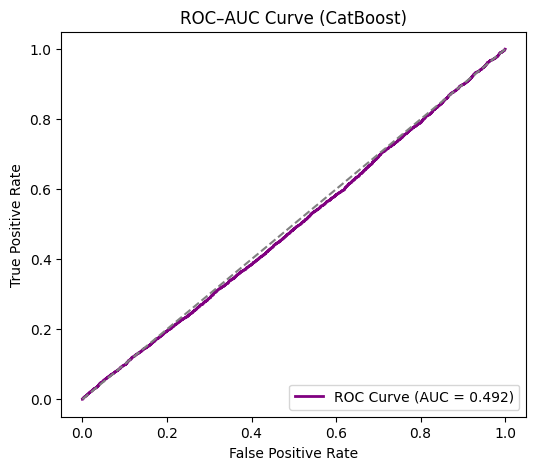

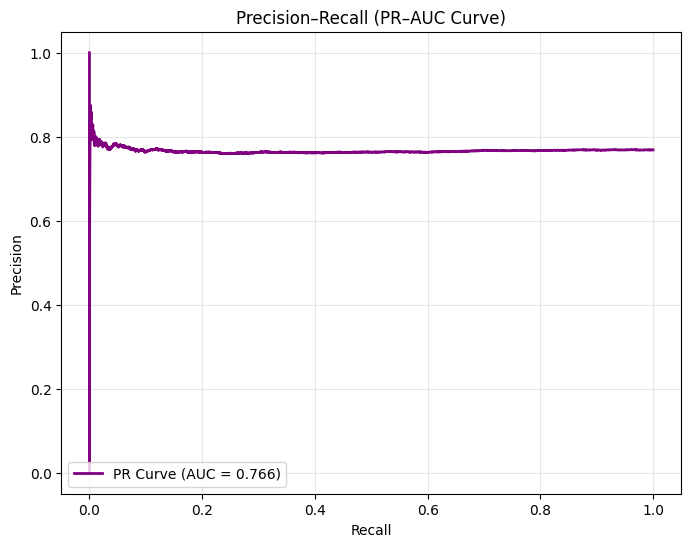

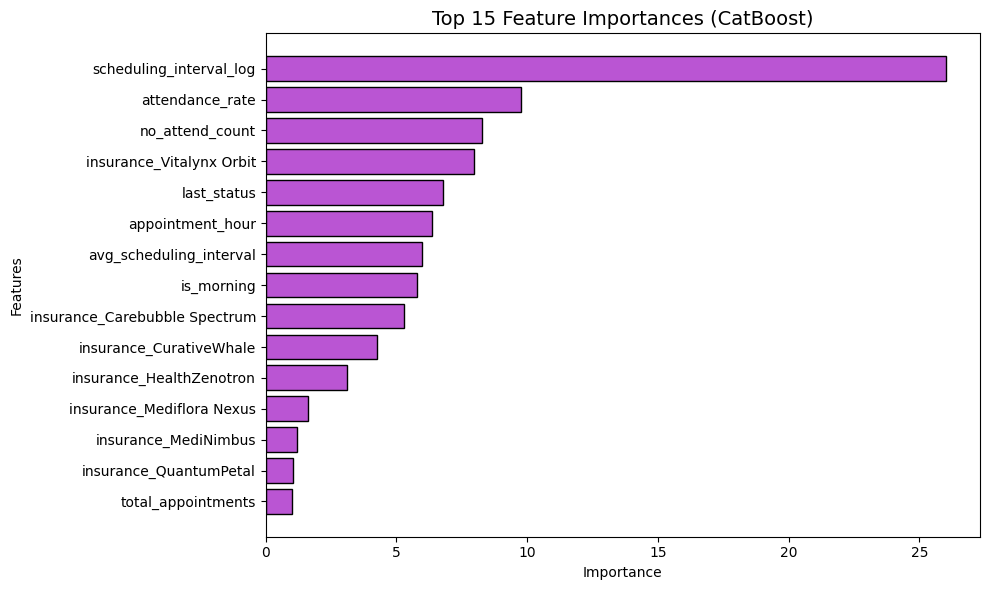

In [ ]:
cat_smtk, cat_imp_df_smtk, cat_auc_smtk = train_catboost_model(
    'chr_smtk',
    X_train_scaled_dict,
    y_train_dict,
    X_test_scaled_chr,
    y_test_chr,
    X_train_chr)